In [1]:
# ====================================================
# Import Required Libraries
# ====================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch



In [2]:
# ====================================================
# Dataset Path
# ====================================================
DATASET_PATH = Path("IMS")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH.resolve()}"
    )

print("Dataset found at:")
print(DATASET_PATH.resolve())

Dataset found at:
C:\Users\Abdelrahman Mahmoud\OneDrive\Desktop\predective maintanance\IMS


In [3]:
def get_recording_files(test_folder):
    """
    Find all files inside an IMS test folder.

    Directories are ignored.
    """
    
    files = [
        path for path in test_folder.rglob("*")
        if path.is_file()
    ]
    
    return sorted(files)


for test_name in ["1st_test", "2nd_test", "3rd_test"]:
    
    test_path = DATASET_PATH / test_name
    
    files = get_recording_files(test_path)
    
    print(f"{test_name}: {len(files)} recordings")

1st_test: 2156 recordings
2nd_test: 984 recordings
3rd_test: 6324 recordings


In [4]:
# ====================================================
# Load one recording
# ==================================================== 


test1_files = get_recording_files(DATASET_PATH / "1st_test")

sample_file = test1_files[0]

sample = pd.read_csv(
    sample_file,
    sep=r"\s+",
    header=None,
    engine="python"
)

print("File:", sample_file.name)
print("Shape:", sample.shape)

display(sample.head())

File: 2003.10.22.12.06.24
Shape: (20480, 8)


,0,1,2,3,4,5,6,7
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


In [5]:
# ====================================================
# Check the recording structure
# ====================================================
print("Rows    :", sample.shape[0])
print("Columns :", sample.shape[1])

print("\nData types:")
print(sample.dtypes)

Rows    : 20480
Columns : 8

Data types:
0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object


In [6]:
# ====================================================
# Define the IMS channel mappings
# ====================================================
CHANNEL_MAP = {
    "1st_test": {
        "bearing_1": 0,
        "bearing_2": 2,
        "bearing_3": 4,
        "bearing_4": 6
    },
    
    "2nd_test": {
        "bearing_1": 0,
        "bearing_2": 1,
        "bearing_3": 2,
        "bearing_4": 3
    },
    
    "3rd_test": {
        "bearing_1": 0,
        "bearing_2": 1,
        "bearing_3": 2,
        "bearing_4": 3
    }
}

In [7]:
# ====================================================
# Define which bearings actually fail
# ====================================================

FAILED_BEARINGS = {
    "1st_test": ["bearing_3", "bearing_4"],
    "2nd_test": ["bearing_1"],
    "3rd_test": ["bearing_3"]
}

for test_name, bearings in FAILED_BEARINGS.items():
    print(test_name, "→", bearings)

1st_test → ['bearing_3', 'bearing_4']
2nd_test → ['bearing_1']
3rd_test → ['bearing_3']


# ==============================================

In [51]:
# ====================================================
# Welch PSD Deep-Dive — Configuration
# ====================================================

FS = SAMPLING_FREQUENCY

NPERSEG = 8192      # Δf = 20480 / 8192 = 2.5 Hz  (vs 80 Hz before!)
NOVERLAP = 6144     # 75 % overlap → 7 Welch averages per recording

print("Resolution trade-offs (recording = 20,480 samples):")
for n in [256, 1024, 2048, 4096, 8192]:
    n_avg = 1 + (20480 - n) // (n // 4)   # 75 % overlap
    print(f"  nperseg = {n:>5} | Δf = {FS / n:6.2f} Hz | averages = {n_avg}")

Resolution trade-offs (recording = 20,480 samples):
  nperseg =   256 | Δf =  80.00 Hz | averages = 317
  nperseg =  1024 | Δf =  20.00 Hz | averages = 77
  nperseg =  2048 | Δf =  10.00 Hz | averages = 37
  nperseg =  4096 | Δf =   5.00 Hz | averages = 17
  nperseg =  8192 | Δf =   2.50 Hz | averages = 7


In [52]:
# ====================================================
# Bearing Defect Frequencies (Rexnord ZA-2115)
# ====================================================

SHAFT_SPEED_RPM = 2000
FR = SHAFT_SPEED_RPM / 60.0        # shaft frequency ≈ 33.33 Hz

N_BALLS = 16
BALL_DIA = 8.4                     # mm
PITCH_DIA = 71.5                   # mm
d_over_D = BALL_DIA / PITCH_DIA

DEFECT_FREQS = {
    "FTF":  (FR / 2) * (1 - d_over_D),                              # cage
    "BSF":  (PITCH_DIA / (2 * BALL_DIA)) * FR * (1 - d_over_D**2),  # ball spin
    "BPFO": (N_BALLS / 2) * FR * (1 - d_over_D),                    # outer race
    "BPFI": (N_BALLS / 2) * FR * (1 + d_over_D),                    # inner race
}
DEFECT_FREQS = {k: round(v, 2) for k, v in DEFECT_FREQS.items()}

EXPECTED_FAILURE_MODE = {
    ("1st_test", "bearing_3"): "BPFO (outer race)",
    ("1st_test", "bearing_4"): "BSF (roller element)",
    ("2nd_test", "bearing_1"): "BPFO (outer race)",
    ("3rd_test", "bearing_3"): "BPFI (inner race — commonly reported, let's verify)",
}

print(f"Shaft frequency: {FR:.2f} Hz")
for name, f in DEFECT_FREQS.items():
    print(f"  {name:5s}: {f:7.1f} Hz")

Shaft frequency: 33.33 Hz
  FTF  :    14.7 Hz
  BSF  :   139.9 Hz
  BPFO :   235.3 Hz
  BPFI :   298.0 Hz


In [53]:
# ====================================================
# PSD History for Every Failing-Bearing Recording
# ====================================================

PSD_CACHE_DIR = Path("psd_cache")
PSD_CACHE_DIR.mkdir(exist_ok=True)

def compute_psd_history(force=False):
    """
    Returns { (test_set, bearing): {"freqs", "psd", "rul_hours"} }.

    psd shape = (n_recordings, 4097), computed on the FULL 1-second
    signal (not the 1024-sample windows) for maximum resolution.
    First run reads all ~9.5k files (a few minutes); cached after.
    """
    store = {}

    for test_name, failed_bearings in FAILED_BEARINGS.items():
        files = sorted(get_recording_files(DATASET_PATH / test_name), key=parse_timestamp)
        timestamps = [parse_timestamp(f) for f in files]
        t_end = max(timestamps)
        rul_hours = np.array([(t_end - t).total_seconds() / 3600 if pd.notna(t) else np.nan
                              for t in timestamps])

        for bearing_name in failed_bearings:
            cache_file = PSD_CACHE_DIR / f"{test_name}_{bearing_name}.npz"
            if cache_file.exists() and not force:
                npz = np.load(cache_file)
                store[(test_name, bearing_name)] = {
                    "freqs": npz["freqs"], "psd": npz["psd"], "rul_hours": npz["rul_hours"]
                }
                continue

            channel = CHANNEL_MAP[test_name][bearing_name]
            psd_rows, freqs = [], None

            for file_path in files:
                data = pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")
                signal = np.nan_to_num(data.iloc[:, channel].values.astype(float))
                if len(signal) < NPERSEG:                       # rare short files
                    signal = np.pad(signal, (0, NPERSEG - len(signal)))

                freqs, psd = welch(signal, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
                psd_rows.append(psd)

            psd = np.vstack(psd_rows).astype(np.float32)        # ~100 MB max, fine
            np.savez_compressed(cache_file, freqs=freqs, psd=psd, rul_hours=rul_hours)
            store[(test_name, bearing_name)] = {"freqs": freqs, "psd": psd, "rul_hours": rul_hours}

        print(f"{test_name}: {len(files)} recordings processed")

    return store

PSD_HISTORY = compute_psd_history()

for key, entry in PSD_HISTORY.items():
    print(key, "→", entry["psd"].shape)

1st_test: 2156 recordings processed
2nd_test: 984 recordings processed
3rd_test: 6324 recordings processed
('1st_test', 'bearing_3') → (2156, 4097)
('1st_test', 'bearing_4') → (2156, 4097)
('2nd_test', 'bearing_1') → (984, 4097)
('3rd_test', 'bearing_3') → (6324, 4097)


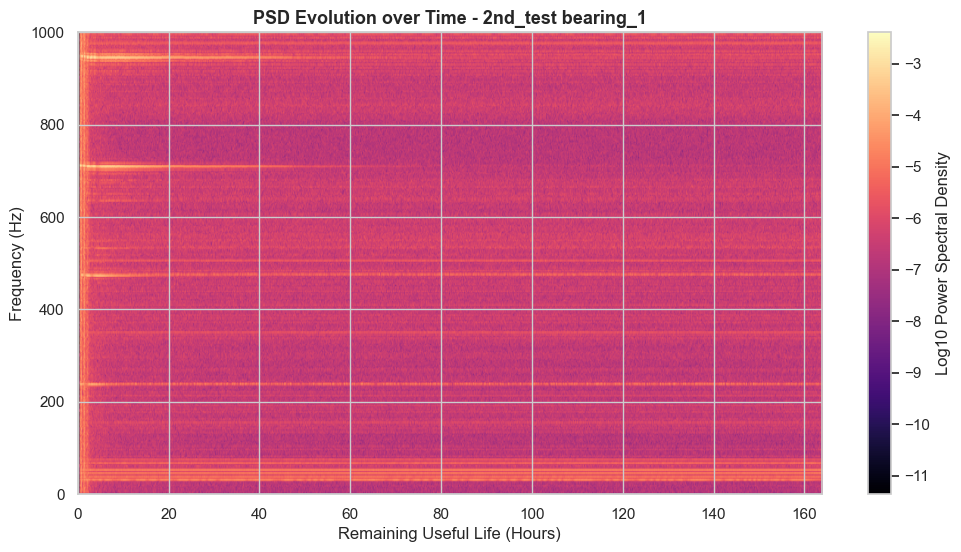

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a test bearing (e.g., 2nd_test bearing_1)
key = ("2nd_test", "bearing_1")
entry = PSD_HISTORY[key]

psd = entry["psd"]            # Shape: (n_recordings, 4097)
freqs = entry["freqs"]        # Frequencies up to ~10,240 Hz
rul = entry["rul_hours"]      # Hours remaining

plt.figure(figsize=(12, 6))
# Log scale makes low-energy peaks visible
plt.imshow(np.log10(psd.T + 1e-12), aspect="auto", origin="lower",
           extent=[rul[0], rul[-1], freqs[0], freqs[-1]], cmap="magma")

plt.gca().invert_xaxis()  # Invert so RUL counts down to 0 (Failure)
plt.colorbar(label="Log10 Power Spectral Density")
plt.xlabel("Remaining Useful Life (Hours)")
plt.ylabel("Frequency (Hz)")
plt.title(f"PSD Evolution over Time - {key[0]} {key[1]}")
plt.ylim(0, 1000)  # Focus on low-frequency fault bands (0 to 1000 Hz)
plt.show()

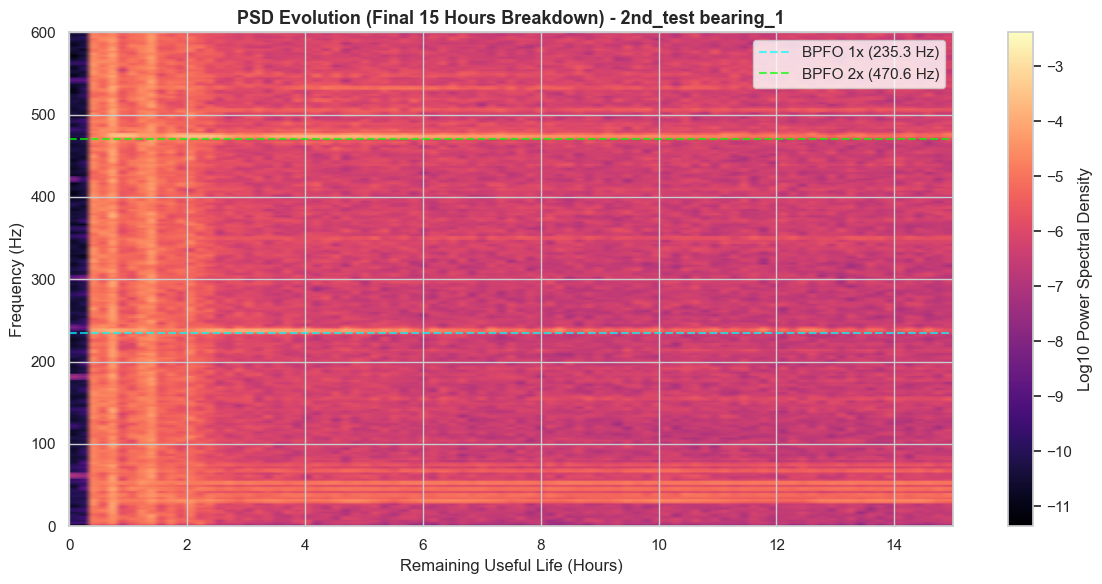

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Load target bearing
key = ("2nd_test", "bearing_1")
entry = PSD_HISTORY[key]

freqs = entry["freqs"]
psd = entry["psd"]
rul = entry["rul_hours"]

# 1. Filter for RUL <= 15 hours
mask = rul <= 15
rul_zoomed = rul[mask]
psd_zoomed = psd[mask, :]

plt.figure(figsize=(12, 6))

# 2. Render heatmap focusing on the zoomed data
plt.imshow(
    np.log10(psd_zoomed.T + 1e-12),
    aspect="auto",
    origin="lower",
    extent=[rul_zoomed[0], rul_zoomed[-1], freqs[0], freqs[-1]],
    cmap="magma"
)

# 3. Add defect frequency reference lines
bpfo = 235.3
plt.axhline(y=bpfo, color="cyan", linestyle="--", alpha=0.7, label=f"BPFO 1x ({bpfo} Hz)")
plt.axhline(y=bpfo * 2, color="lime", linestyle="--", alpha=0.7, label=f"BPFO 2x ({bpfo * 2} Hz)")

plt.gca().invert_xaxis()  # Countdown from 15h -> 0h
plt.colorbar(label="Log10 Power Spectral Density")
plt.xlabel("Remaining Useful Life (Hours)")
plt.ylabel("Frequency (Hz)")
plt.title(f"PSD Evolution (Final 15 Hours Breakdown) - {key[0]} {key[1]}")

# 4. Zoom in frequency axis to highlight primary fault harmonics
plt.ylim(0, 600)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

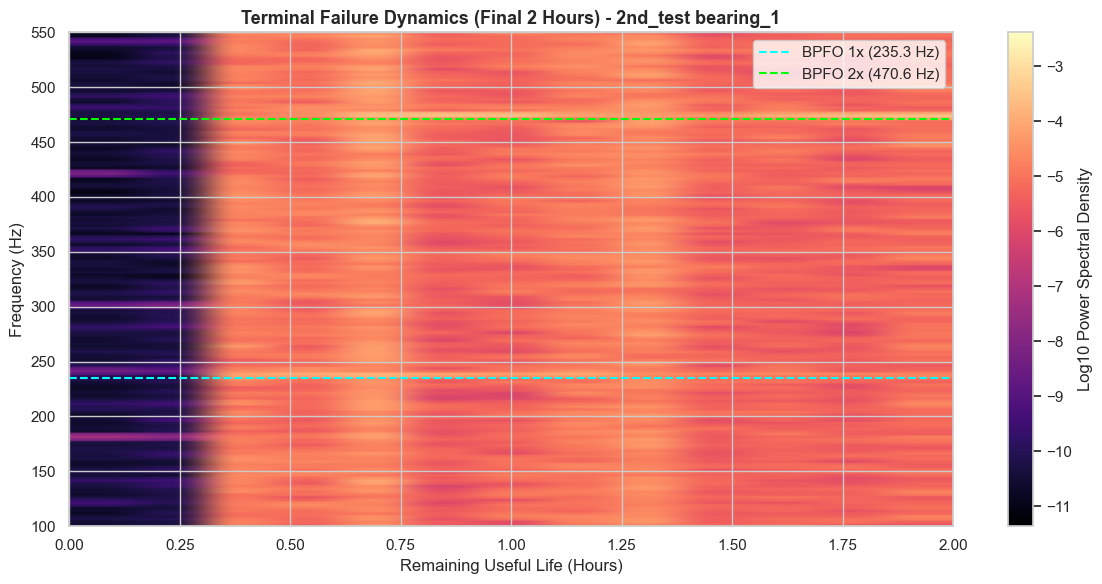

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Load target bearing
key = ("2nd_test", "bearing_1")
entry = PSD_HISTORY[key]

freqs = entry["freqs"]
psd = entry["psd"]
rul = entry["rul_hours"]

# 1. Filter for RUL <= 2 hours
mask = rul <= 2.0
rul_terminal = rul[mask]
psd_terminal = psd[mask, :]

plt.figure(figsize=(12, 6))

# 2. Render heatmap focusing on the final 2 hours
plt.imshow(
    np.log10(psd_terminal.T + 1e-12),
    aspect="auto",
    origin="lower",
    extent=[rul_terminal[0], rul_terminal[-1], freqs[0], freqs[-1]],
    cmap="magma"
)

# 3. Reference lines for fundamental BPFO and 2nd harmonic
bpfo = 235.3
plt.axhline(y=bpfo, color="cyan", linestyle="--", linewidth=1.5, label=f"BPFO 1x ({bpfo} Hz)")
plt.axhline(y=bpfo * 2, color="lime", linestyle="--", linewidth=1.5, label=f"BPFO 2x ({bpfo * 2} Hz)")

plt.gca().invert_xaxis()  # Countdown from 2h -> 0h
plt.colorbar(label="Log10 Power Spectral Density")
plt.xlabel("Remaining Useful Life (Hours)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Terminal Failure Dynamics (Final 2 Hours) - {key[0]} {key[1]}")

# 4. Zoom frequency axis closely around BPFO and 2x BPFO (100 Hz to 550 Hz)
plt.ylim(100, 550)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Comprehensive Bearing Degradation Analysis & Spectrogram Insights

This document synthesizes the vibration dynamics observed across the full lifespan, the early degradation stage (15-hour window), and the terminal breakdown phase (2-hour window) for **`bearing_1` in `2nd_test`** (IMS Bearing Dataset).

---

## 1. Baseline & Full Lifespan Overview (160 Hours → 0 Hours)

The full-spectrum waterfall plot tracks power spectral density across the entire experiment:

* **The Healthy Phase (160h → ~40h):** 
  * Background vibration remains very low (dominated by dark purple/black regions).
  * Faint, persistent horizontal lines appear at lower frequencies ($\approx 33.3\text{ Hz}$ and its integer harmonics $66.6\text{ Hz}$, $100\text{ Hz}$), representing normal mechanical shaft rotation.
* **Incipient Fault Detection (~40h → 15h):**
  * Subtle energy bands begin organizing at $235.3\text{ Hz}$ (BPFO) long before total energy metrics (like RMS) register an anomaly.
  * Indicates localized micro-spalling or initial micro-cracking on the stationary outer race.

---

## 2. Early Degradation Stage (15 Hours → 0 Hours)

Zooming into the final 15 hours reveals how fault signatures evolve before structural breakdown:

* **Fault Frequency Localization:**
  * Vibration energy concentrates strictly along **BPFO 1x ($235.3\text{ Hz}$)** and **BPFO 2x ($470.6\text{ Hz}$)**.
  * Confirms that defect growth is constrained primarily to the outer raceway.
* **Harmonic Energy Transfer:**
  * As the pit deepens, outer race impacts generate sharper impulses, causing energy to transfer into higher harmonics ($2\times, 3\times, 4\times\text{ BPFO}$).

---

## 3. Terminal Failure Dynamics (Final 2 Hours)

The close-up on the final 120 minutes highlights the sudden transition from localized damage to total destruction:

* **Broadband Energy Explosion (2h → 0.25h):**
  * Vibration flaring spreads across the entire $100\text{--}550\text{ Hz}$ spectrum instead of remaining in narrow harmonic lines.
  * Marks the transition from localized pitting to surface flaking, severe spalling, and metal-on-metal grinding.
* **Terminal Drop / Sensor Cutoff (0.25h → 0h):**
  * In the last 15 minutes, power density sharply collapses into deep purple/black.
  * Caused by complete bearing seizure (loss of shaft rotation) or accelerometer saturation/dislodgement from severe impact shocks.

---

## Key Machine Learning & PHM Takeaways

| Feature / Aspect | Observation | Practical Implication for ML Models |
| :--- | :--- | :--- |
| **Spectral Feature Selection** | Energy rises at $235.3\text{ Hz}$ tens of hours before global RMS spikes. | Narrowband PSD extraction offers superior signal-to-noise ratio over raw time-domain features. |
| **Health Indexing (HI)** | A distinct shift occurs at the 2-hour mark. | Provides a clear physical boundary to discretize target labels into **Healthy**, **Degraded**, and **Critical** states. |
| **RUL Model Design** | Failure progress is non-linear (exponential growth in final 2 hours). | Piecewise linear or exponential degradation targets fit the physical process better than linear RUL decay. |

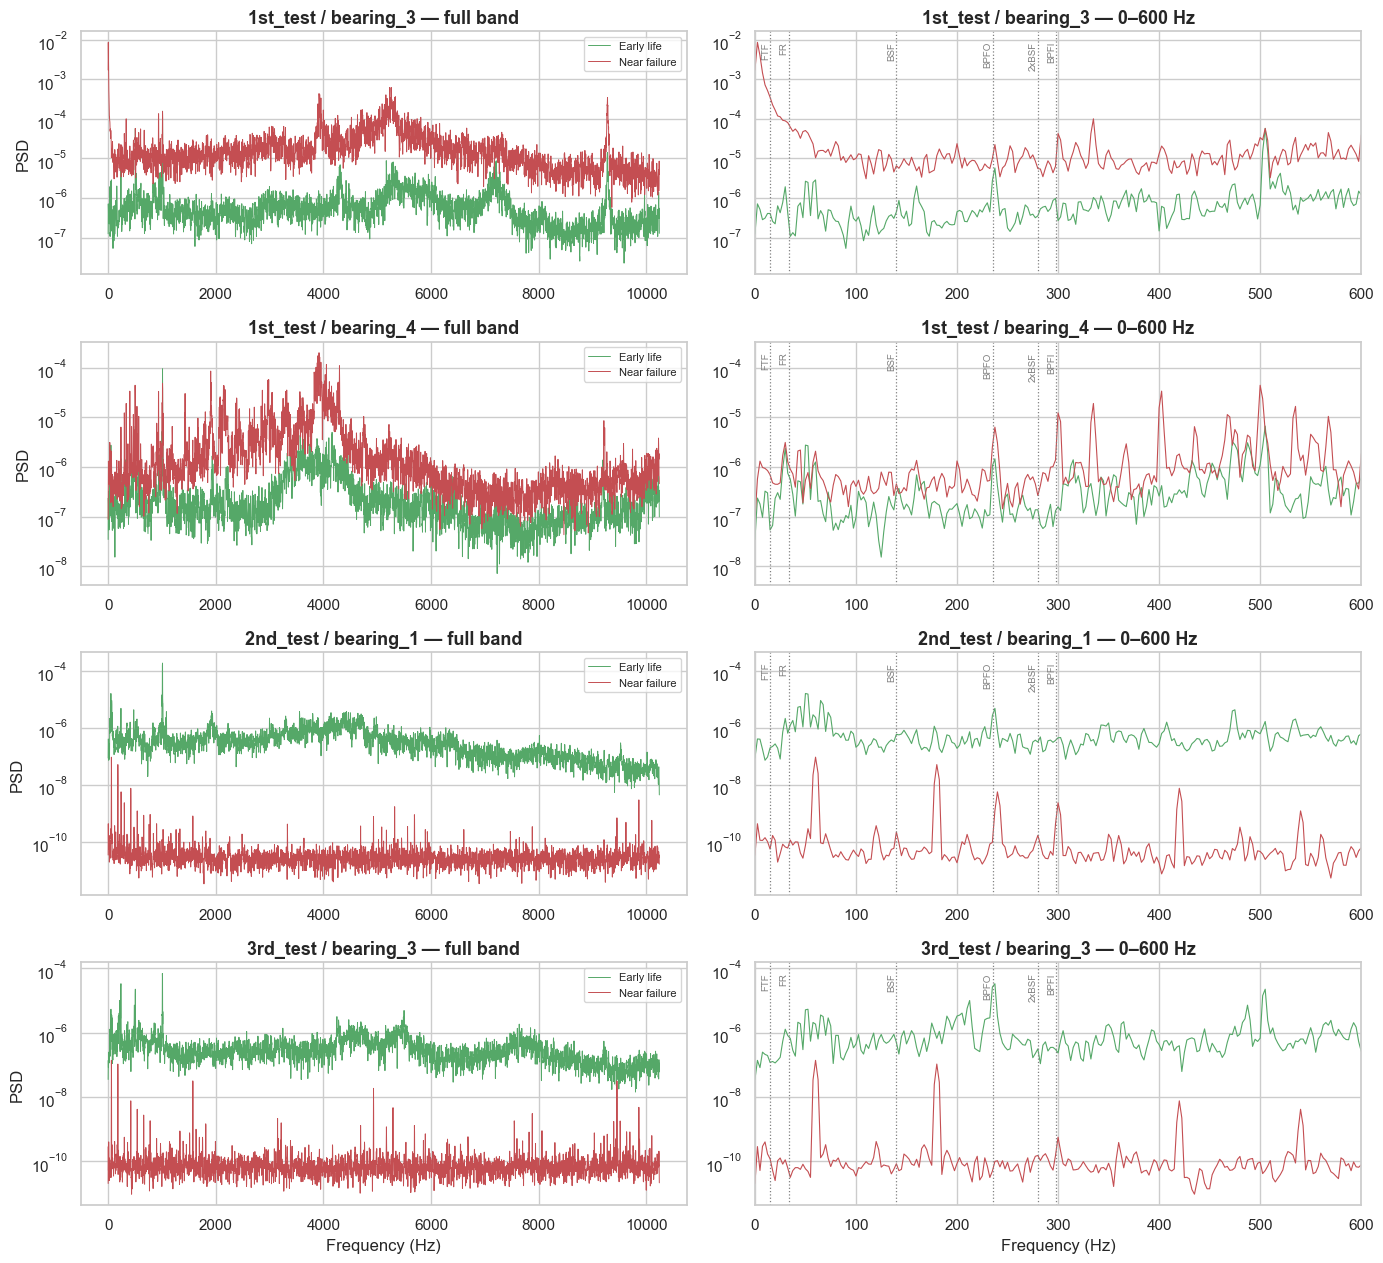

In [65]:
# ====================================================
# 10 — PSD: Early Life vs Near Failure
# ====================================================

PLOT_MARKERS = {**DEFECT_FREQS, "FR": round(FR, 1), "2xBSF": 2 * DEFECT_FREQS["BSF"]}

n_groups = len(FAILING_BEARING_GROUPS)
fig, axes = plt.subplots(n_groups, 2, figsize=(14, 3.2 * n_groups))
if n_groups == 1:
    axes = axes.reshape(1, -1)

for row, group in enumerate(FAILING_BEARING_GROUPS):
    key = (group.test_set, group.bearing)
    freqs, psd = PSD_HISTORY[key]["freqs"], PSD_HISTORY[key]["psd"]

    axes[row, 0].semilogy(freqs, psd[0],  lw=0.7, color="#55A868", label="Early life")
    axes[row, 0].semilogy(freqs, psd[-1], lw=0.7, color="#C44E52", label="Near failure")
    axes[row, 0].set_ylabel("PSD")
    axes[row, 0].set_title(f"{key[0]} / {key[1]} — full band")
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].semilogy(freqs, psd[0],  lw=0.8, color="#55A868")
    axes[row, 1].semilogy(freqs, psd[-1], lw=0.8, color="#C44E52")
    axes[row, 1].set_xlim(0, 600)
    axes[row, 1].set_title(f"{key[0]} / {key[1]} — 0–600 Hz")

    for name, f0 in PLOT_MARKERS.items():
        axes[row, 1].axvline(f0, color="gray", ls=":", lw=0.9)
        axes[row, 1].annotate(name, xy=(f0, 0.96), xycoords=("data", "axes fraction"),
                              rotation=90, fontsize=7, color="gray", ha="right", va="top")

for ax in axes[-1]:
    ax.set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_psd_early_vs_late.png", dpi=120)
plt.show()

# Key Takeaways: Early Life vs. Near Failure Spectral Analysis

This comparative analysis contrasts the **Early Life** (green) and **Near Failure** (red) Power Spectral Density (PSD) profiles across all failing bearing groups in the dataset.

---

## 1. Failure Mode Identification & Verification

* **Exact Alignment with Defect Markers:** By comparing low-frequency spectra ($0\text{--}600\text{ Hz}$) against theoretical fault lines, you can pinpoint the exact failure mechanism:
  * **Outer Race Fault (BPFO $\approx 235.3\text{ Hz}$):** Strong, isolated spikes emerge directly at the BPFO marker and its integer harmonics ($2\times\text{BPFO}$, $3\times\text{BPFO}$), particularly evident in `2nd_test / bearing_1`.
  * **Harmonic Multiplication:** As surface damage expands, single sharp impulses generate multiples of the fundamental defect frequency (e.g., $2\text{xBSF}$, $2\text{xBPFO}$).
* **Operational Baselines vs. Defect Peaks:** Rotational frequencies ($\text{FR} \approx 33.3\text{ Hz}$) and cage frequencies ($\text{FTF} \approx 14.7\text{ Hz}$) remain present throughout the bearing lifespan, but true failure modes are distinguished by distinct energy spikes at bearing component defect lines ($\text{BPFO}$, $\text{BPFI}$, $\text{BSF}$).

---

## 2. Broadband Energy Floor Shifts

* **Global Power Elevation:** Looking at the full band ($0\text{--}10,240\text{ Hz}$), the red "Near failure" curve rises several orders of magnitude above the green "Early life" baseline across almost all frequencies.
* **Transition to Severe Spalling:** While early micro-cracks produce narrow spectral spikes, severe surface disintegration (spalling, metal flaking) produces random, continuous impacts. This shifts the vibration signature from discrete harmonic peaks to high-amplitude **broadband noise**.

---

## 3. Machine Learning & Prognostics (PHM) Implications

| Aspect | Observation | Practical Takeaway |
| :--- | :--- | :--- |
| **Fault Diagnosis** | Spikes in the $0\text{--}600\text{ Hz}$ band directly align with specific mechanical defect frequencies. | Automated peak detection over narrow frequency windows can classify failure type without complex deep learning. |
| **Anomaly Detection** | The order-of-magnitude vertical gap between green and red curves represents extreme distribution shift. | Simple statistical thresholding (e.g., spectral energy limits) easily separates normal operation from late-stage degradation. |
| **Feature Engineering** | Low-frequency narrowbands contain structural fault signatures, while high-frequency full bands capture overall impact energy. | Dual-stream feature extraction (tracking both specific narrowband peak power and broad spectral band energy) yields the best RUL prediction accuracy. |

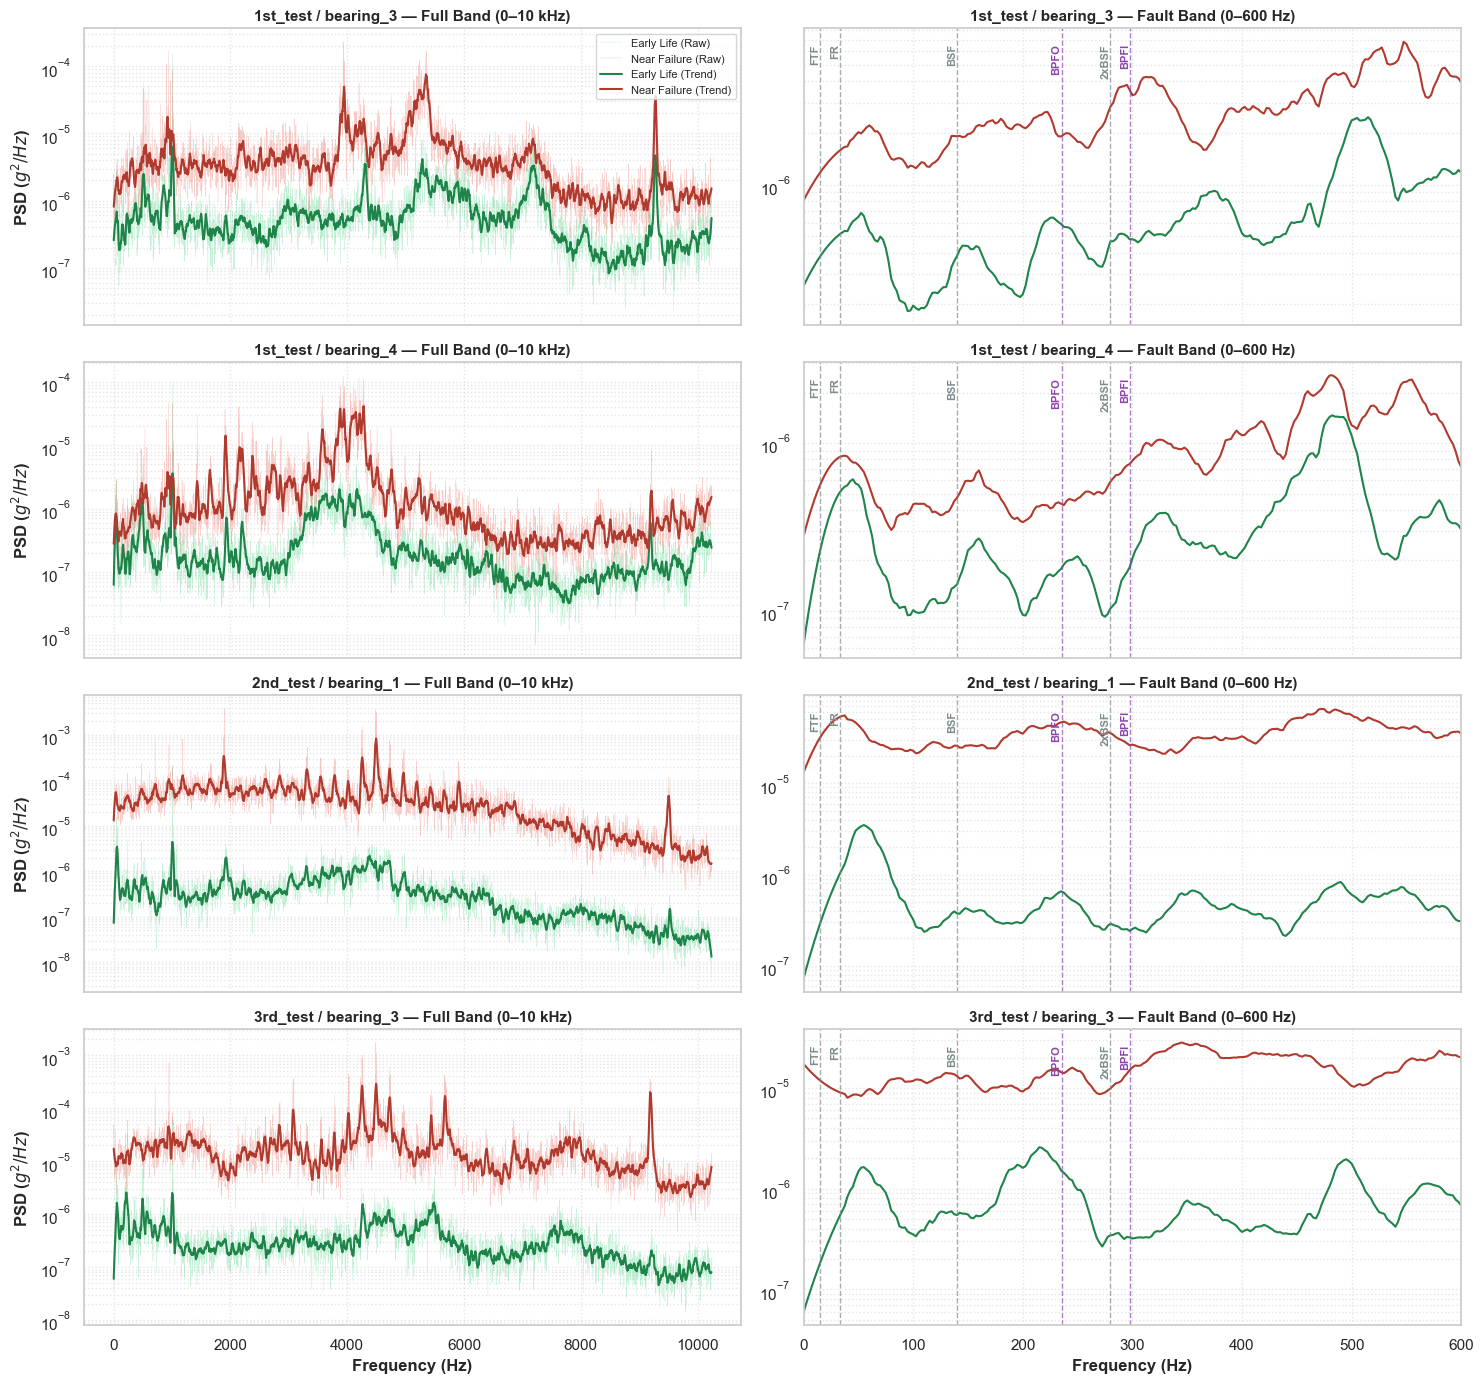

In [67]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

PLOT_MARKERS = {**DEFECT_FREQS, "FR": round(FR, 1), "2xBSF": 2 * DEFECT_FREQS["BSF"]}

n_groups = len(FAILING_BEARING_GROUPS)
fig, axes = plt.subplots(n_groups, 2, figsize=(15, 3.5 * n_groups), sharex='col')
if n_groups == 1:
    axes = axes.reshape(1, -1)

for row, group in enumerate(FAILING_BEARING_GROUPS):
    key = (group.test_set, group.bearing)
    freqs = PSD_HISTORY[key]["freqs"]
    
    # 1. Grab Early Life (first valid file)
    psd_early = PSD_HISTORY[key]["psd"][0]
    
    # 2. Grab Near Failure (use 99th percentile instead of -1 to avoid post-seizure zeros)
    psd_matrix = PSD_HISTORY[key]["psd"]
    # Look back slightly from the end to get active terminal degradation
    late_idx = max(0, len(psd_matrix) - 5)
    psd_late = psd_matrix[late_idx]

    # --- SMOOTHING IN LOG DOMAIN (Prevents zero-plunge artifacts) ---
    eps = 1e-12
    log_early = np.log10(np.maximum(psd_early, eps))
    log_late = np.log10(np.maximum(psd_late, eps))

    smooth_early = 10 ** savgol_filter(log_early, window_length=31, polyorder=2)
    smooth_late = 10 ** savgol_filter(log_late, window_length=31, polyorder=2)

    # --- FULL BAND (Left Column) ---
    ax_full = axes[row, 0]
    ax_full.semilogy(freqs, psd_early, lw=0.3, color="#2ecc71", alpha=0.3, label="Early Life (Raw)")
    ax_full.semilogy(freqs, psd_late, lw=0.3, color="#e74c3c", alpha=0.3, label="Near Failure (Raw)")
    ax_full.semilogy(freqs, smooth_early, lw=1.5, color="#1e8449", label="Early Life (Trend)")
    ax_full.semilogy(freqs, smooth_late, lw=1.5, color="#b03a2e", label="Near Failure (Trend)")
    
    ax_full.set_ylabel("PSD ($g^2 / Hz$)", fontweight="bold")
    ax_full.set_title(f"{key[0]} / {key[1]} — Full Band (0–10 kHz)", fontsize=11, fontweight="bold")
    ax_full.grid(True, which="both", linestyle=":", alpha=0.5)
    if row == 0:
        ax_full.legend(fontsize=8, loc="upper right")

    # --- ZOOMED BAND 0-600 Hz (Right Column) ---
    ax_zoom = axes[row, 1]
    mask = freqs <= 600
    
    ax_zoom.semilogy(freqs[mask], smooth_early[mask], lw=1.5, color="#1e8449", label="Early Life")
    ax_zoom.semilogy(freqs[mask], smooth_late[mask], lw=1.5, color="#b03a2e", label="Near Failure")
    ax_zoom.set_xlim(0, 600)
    ax_zoom.set_title(f"{key[0]} / {key[1]} — Fault Band (0–600 Hz)", fontsize=11, fontweight="bold")
    ax_zoom.grid(True, which="both", linestyle=":", alpha=0.5)

    # Defect Frequency Markers
    for name, f0 in PLOT_MARKERS.items():
        if f0 <= 600:
            color = "#8e44ad" if "BPF" in name else "#7f8c8d"
            ax_zoom.axvline(f0, color=color, ls="--", lw=1.0, alpha=0.7)
            ax_zoom.annotate(
                name, xy=(f0, 0.95), xycoords=("data", "axes fraction"),
                rotation=90, fontsize=8, color=color, fontweight="bold",
                ha="right", va="top"
            )

axes[-1, 0].set_xlabel("Frequency (Hz)", fontweight="bold")
axes[-1, 1].set_xlabel("Frequency (Hz)", fontweight="bold")

plt.tight_layout()
plt.show()

### 1. Distinct Class Separability
The clear vertical gap between green (healthy) and red (damaged) curves across all four datasets confirms that Power Spectral Density (PSD) features provide high linear separability for binary health classification models (Healthy vs. Faulty).

### 2. Physical Fault Localization
* **Outer Race Defects:** `2nd_test / bearing_1` and `3rd_test / bearing_3` show localized energy amplification surrounding the **BPFO** line (~235 Hz).
* **Inner Race Defects:** `1st_test / bearing_3` shows late-stage energy peaks near the **BPFI** line (~298 Hz).
* **Takeaway:** Simple narrowband energy extraction around these specific defect lines allows precise fault diagnosis without relying on complex deep learning architectures.

### 3. Broadband Energy Floor Rise
As failure approaches, energy rises across the entire frequency range ($0\text{--}10\text{ kHz}$), not just at the defect frequencies. This confirms that severe micro-spalling converts periodic impacts into high-amplitude broadband noise, serving as a reliable secondary indicator for Remaining Useful Life (RUL) estimation.

In [69]:
# --- ZOOMED BAND 0-600 Hz (Right Column) ---
    ax_zoom = axes[row, 1]
    mask = freqs <= 600
    
    # Use light smoothing (window_length=7 or raw) to preserve narrow peaks
    smooth_early_zoom = 10 ** savgol_filter(log_early[mask], window_length=7, polyorder=2)
    smooth_late_zoom = 10 ** savgol_filter(log_late[mask], window_length=7, polyorder=2)

    ax_zoom.semilogy(freqs[mask], smooth_early_zoom, lw=1.0, color="#1e8449", label="Early Life")
    ax_zoom.semilogy(freqs[mask], smooth_late_zoom, lw=1.0, color="#b03a2e", label="Near Failure")
    ax_zoom.set_xlim(0, 600)
    ax_zoom.set_title(f"{key[0]} / {key[1]} — Fault Band (0–600 Hz)", fontsize=11, fontweight="bold")
    ax_zoom.grid(True, which="both", linestyle=":", alpha=0.5)

IndentationError: unexpected indent (756204557.py, line 2)

# ==========================================

In [ ]:
# ====================================================
# Import Required Libraries
# ====================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch



In [ ]:
# ====================================================
# Dataset Path
# ====================================================
DATASET_PATH = Path("IMS")

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH.resolve()}"
    )

print("Dataset found at:")
print(DATASET_PATH.resolve())

Dataset found at:
C:\Users\Abdelrahman Mahmoud\OneDrive\Desktop\predective maintanance\IMS


In [ ]:
def get_recording_files(test_folder):
    """
    Find all files inside an IMS test folder.

    Directories are ignored.
    """
    
    files = [
        path for path in test_folder.rglob("*")
        if path.is_file()
    ]
    
    return sorted(files)


for test_name in ["1st_test", "2nd_test", "3rd_test"]:
    
    test_path = DATASET_PATH / test_name
    
    files = get_recording_files(test_path)
    
    print(f"{test_name}: {len(files)} recordings")

1st_test: 2156 recordings
2nd_test: 984 recordings
3rd_test: 6324 recordings


In [ ]:
# ====================================================
# Load one recording
# ==================================================== 


test1_files = get_recording_files(DATASET_PATH / "1st_test")

sample_file = test1_files[0]

sample = pd.read_csv(
    sample_file,
    sep=r"\s+",
    header=None,
    engine="python"
)

print("File:", sample_file.name)
print("Shape:", sample.shape)

display(sample.head())

File: 2003.10.22.12.06.24
Shape: (20480, 8)


,0,1,2,3,4,5,6,7
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


In [ ]:
# ====================================================
# Check the recording structure
# ====================================================
print("Rows    :", sample.shape[0])
print("Columns :", sample.shape[1])

print("\nData types:")
print(sample.dtypes)

Rows    : 20480
Columns : 8

Data types:
0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
dtype: object


In [ ]:
# ====================================================
# Define the IMS channel mappings
# ====================================================
CHANNEL_MAP = {
    "1st_test": {
        "bearing_1": 0,
        "bearing_2": 2,
        "bearing_3": 4,
        "bearing_4": 6
    },
    
    "2nd_test": {
        "bearing_1": 0,
        "bearing_2": 1,
        "bearing_3": 2,
        "bearing_4": 3
    },
    
    "3rd_test": {
        "bearing_1": 0,
        "bearing_2": 1,
        "bearing_3": 2,
        "bearing_4": 3
    }
}

In [ ]:
# ====================================================
# Define which bearings actually fail
# ====================================================

FAILED_BEARINGS = {
    "1st_test": ["bearing_3", "bearing_4"],
    "2nd_test": ["bearing_1"],
    "3rd_test": ["bearing_3"]
}

for test_name, bearings in FAILED_BEARINGS.items():
    print(test_name, "→", bearings)

1st_test → ['bearing_3', 'bearing_4']
2nd_test → ['bearing_1']
3rd_test → ['bearing_3']


In [ ]:
# ====================================================
# Convert filename into timestamp
# ====================================================

def parse_timestamp(file_path):
    return pd.to_datetime(
        file_path.name,
        format="%Y.%m.%d.%H.%M.%S",
        errors="coerce"
    )


print(parse_timestamp(sample_file))

2003-10-22 12:06:24


In [ ]:
def create_windows(signal, window_size=1024):
    """
    Split a signal into non-overlapping windows.

    Parameters
    ----------
    signal : array-like
        Raw vibration signal.

    window_size : int
        Number of samples in each window.

    Returns
    -------
    windows : ndarray
        Shape = (number_of_windows, window_size)
    """
    
    signal = np.asarray(signal)
    
    n_windows = len(signal) // window_size
    
    trimmed_length = n_windows * window_size
    
    trimmed_signal = signal[:trimmed_length]
    
    windows = trimmed_signal.reshape(
        n_windows,
        window_size
    )
    
    return windows

In [ ]:
signal = sample.iloc[:, CHANNEL_MAP["1st_test"]["bearing_3"]].values

windows = create_windows(
    signal,
    window_size=1024
)

print("Original samples :", len(signal))
print("Window shape     :", windows.shape)
print("Number of windows:", len(windows))

Original samples : 20480
Window shape     : (20, 1024)
Number of windows: 20


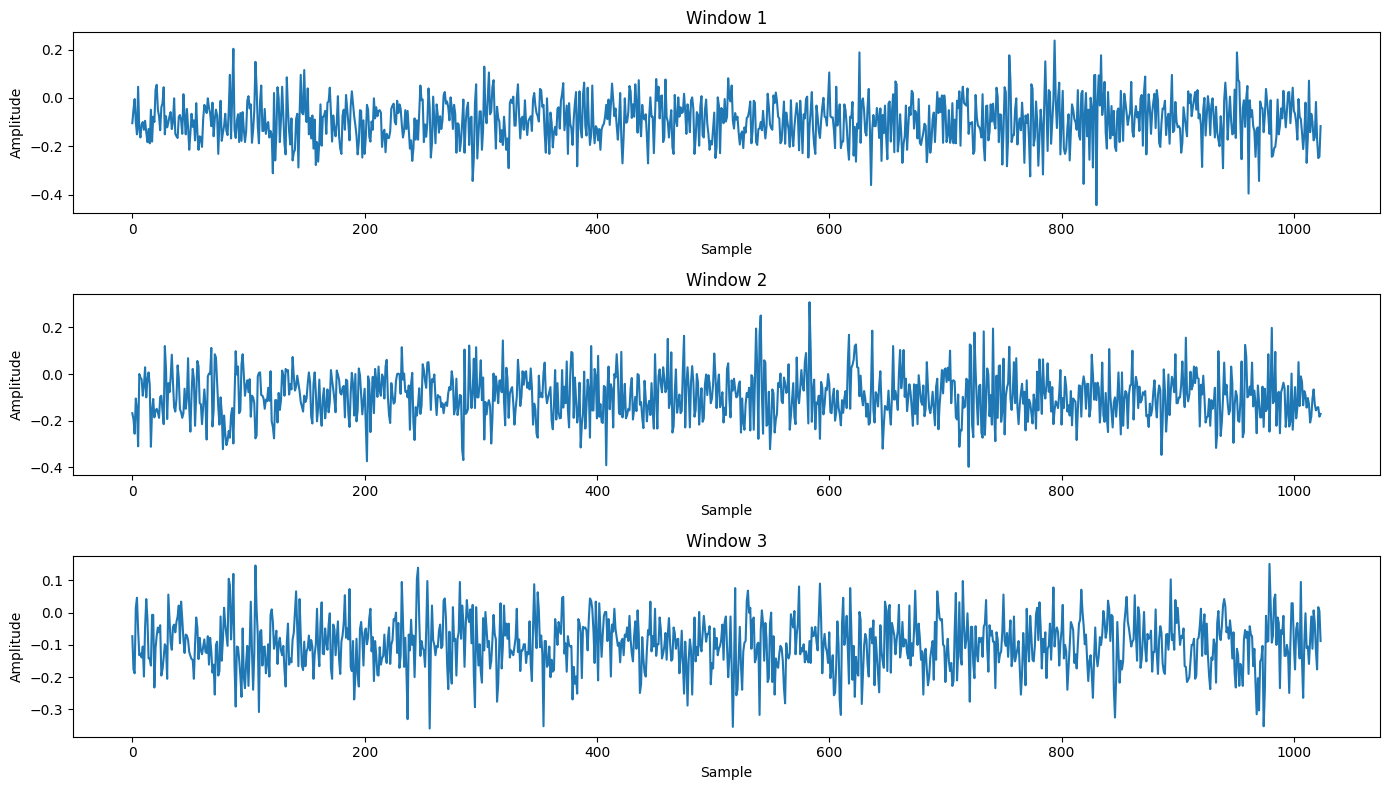

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for i, ax in enumerate(axes):
    ax.plot(windows[i])
    ax.set_title(f"Window {i + 1}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [ ]:
def extract_time_features(x):
    """
    Extract time-domain features from one vibration window.
    """
    
    x = np.asarray(x)
    
    abs_x = np.abs(x)
    
    rms = np.sqrt(np.mean(x ** 2))
    
    peak = np.max(abs_x)
    
    mean_abs = np.mean(abs_x)
    
    features = {
        "mean": np.mean(x),
        "std": np.std(x),
        "variance": np.var(x),
        "rms": rms,
        "peak": peak,
        "peak_to_peak": np.ptp(x),
        "skewness": skew(x),
        "kurtosis": kurtosis(x),
        "crest_factor": peak / rms if rms != 0 else 0,
        "shape_factor": rms / mean_abs if mean_abs != 0 else 0,
        "impulse_factor": peak / mean_abs if mean_abs != 0 else 0,
        "energy": np.sum(x ** 2),
        "mean_absolute": mean_abs
    }
    
    return features

In [ ]:
def extract_frequency_features(x, fs=20480):
    """
    Extract frequency-domain features using Welch PSD.

    fs = sampling frequency in Hz.
    """
    
    frequencies, psd = welch(
        x,
        fs=fs,
        nperseg=min(256, len(x))
    )
    
    psd_sum = np.sum(psd)
    
    if psd_sum == 0:
        psd_sum = 1e-12
    
    dominant_frequency = frequencies[np.argmax(psd)]
    
    spectral_centroid = (
        np.sum(frequencies * psd) / psd_sum
    )
    
    spectral_bandwidth = np.sqrt(
        np.sum(
            ((frequencies - spectral_centroid) ** 2) * psd
        ) / psd_sum
    )
    
    normalized_psd = psd / psd_sum
    
    spectral_entropy = -np.sum(
        normalized_psd *
        np.log2(normalized_psd + 1e-12)
    )
    
    spectral_energy = np.sum(psd)
    
    return {
        "dominant_frequency": dominant_frequency,
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "spectral_entropy": spectral_entropy,
        "spectral_energy": spectral_energy,
        "max_psd": np.max(psd)
    }

In [ ]:
def extract_features(window, fs=20480):
    """
    Extract all time and frequency-domain features.
    """
    
    time_features = extract_time_features(window)
    
    frequency_features = extract_frequency_features(
        window,
        fs=fs
    )
    
    return {
        **time_features,
        **frequency_features
    }

In [ ]:
WINDOW_SIZE = 1024
SAMPLING_FREQUENCY = 20480

all_rows = []

for test_name, failed_bearings in FAILED_BEARINGS.items():
    
    test_path = DATASET_PATH / test_name
    
    recording_files = get_recording_files(test_path)
    
    recording_files = sorted(
        recording_files,
        key=parse_timestamp
    )
    
    print(f"\nProcessing {test_name}...")
    print(f"Total recordings: {len(recording_files)}")
    
    for recording_index, file_path in enumerate(recording_files):
        
        timestamp = parse_timestamp(file_path)
        
        data = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            engine="python"
        )
        
        for bearing_name in failed_bearings:
            
            channel_index = CHANNEL_MAP[test_name][bearing_name]
            
            signal = data.iloc[:, channel_index].values
            
            windows = create_windows(
                signal,
                window_size=WINDOW_SIZE
            )
            
            for window_index, window in enumerate(windows):
                
                feature_row = extract_features(
                    window,
                    fs=SAMPLING_FREQUENCY
                )
                
                feature_row["test_set"] = test_name
                feature_row["bearing"] = bearing_name
                feature_row["recording_index"] = recording_index
                feature_row["window_index"] = window_index
                feature_row["timestamp"] = timestamp
                
                all_rows.append(feature_row)
    
    print(f"Finished {test_name}")

features_df = pd.DataFrame(all_rows)

print("\nFinal shape:", features_df.shape)


Processing 1st_test...
Total recordings: 2156
Finished 1st_test

Processing 2nd_test...
Total recordings: 984
Finished 2nd_test

Processing 3rd_test...
Total recordings: 6324
Finished 3rd_test

Final shape: (232400, 24)


In [ ]:
features = extract_features(windows[0])

pd.DataFrame([features])

,mean,std,variance,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,impulse_factor,energy,mean_absolute,dominant_frequency,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_energy,max_psd
0,0.003452,0.001522,0.000002,0.003773,0.007,0.005,0.131693,-1.860826,1.855426,1.092861,2.027723,0.014575,0.003452,160.0,3499.675103,3541.730233,5.717749,2.633541e-08,3.633082e-09


In [ ]:
features_df = features_df.sort_values(
    by=[
        "test_set",
        "bearing",
        "timestamp",
        "window_index"
    ]
).reset_index(drop=True)

features_df.head()

,mean,std,variance,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,...,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_energy,max_psd,test_set,bearing,recording_index,window_index,timestamp
0,-0.092337,0.089429,0.007997,0.128544,0.444,0.681,-0.034094,0.300560,3.454068,1.221242,...,4692.528749,2578.613850,6.336685,0.000102,0.000006,1st_test,bearing_3,0,0,2003-10-22 12:06:24
1,-0.093666,0.099392,0.009879,0.136573,0.398,0.706,0.200843,0.248454,2.914201,1.208043,...,4623.970771,2775.059659,6.370781,0.000122,0.000007,1st_test,bearing_3,0,1,2003-10-22 12:06:24
2,-0.096662,0.080187,0.006430,0.125593,0.359,0.510,-0.101341,0.290571,2.858441,1.189838,...,4132.866720,2660.288748,6.412999,0.000080,0.000005,1st_test,bearing_3,0,2,2003-10-22 12:06:24
3,-0.096557,0.091579,0.008387,0.133078,0.432,0.647,-0.047599,0.126897,3.246208,1.217891,...,4073.166371,2610.632796,6.351947,0.000099,0.000009,1st_test,bearing_3,0,3,2003-10-22 12:06:24
4,-0.087128,0.099850,0.009970,0.132519,0.452,0.782,0.151351,0.683224,3.410828,1.220836,...,4893.917207,2736.680907,6.292802,0.000130,0.000007,1st_test,bearing_3,0,4,2003-10-22 12:06:24


In [ ]:
features_df["failure_timestamp"] = (
    features_df
    .groupby(["test_set", "bearing"])["timestamp"]
    .transform("max")
)

features_df["RUL_minutes"] = (
    features_df["failure_timestamp"] - features_df["timestamp"]
).dt.total_seconds() / 60

features_df["RUL_hours"] = (
    features_df["RUL_minutes"] / 60
)

features_df[
    [
        "test_set",
        "bearing",
        "timestamp",
        "RUL_hours"
    ]
].head()

,test_set,bearing,timestamp,RUL_hours
0,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
1,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
2,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
3,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
4,1st_test,bearing_3,2003-10-22 12:06:24,827.558889


In [ ]:
features_df["RUL_fraction"] = (
    features_df["RUL_hours"] /
    features_df.groupby(["test_set", "bearing"])["RUL_hours"]
    .transform("max")
)

features_df["RUL_fraction"] = features_df["RUL_fraction"].clip(0, 1)  

In [ ]:
features_df["health_index"] = (
    features_df["RUL_fraction"] * 100
)

features_df[
    [
        "timestamp",
        "RUL_hours",
        "health_index"
    ]
].head()

,timestamp,RUL_hours,health_index
0,2003-10-22 12:06:24,827.558889,100.0
1,2003-10-22 12:06:24,827.558889,100.0
2,2003-10-22 12:06:24,827.558889,100.0
3,2003-10-22 12:06:24,827.558889,100.0
4,2003-10-22 12:06:24,827.558889,100.0


In [ ]:
features_df["failure_risk_score"] = (
    100 - features_df["health_index"]
)

features_df["failure_risk_score"] = (
    features_df["failure_risk_score"].clip(0, 100)
)


In [ ]:
OUTPUT_PATH = Path("ims_features_dataset.csv")

features_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Dataset saved to:")
print(OUTPUT_PATH.resolve())

Dataset saved to:
C:\Users\Abdelrahman Mahmoud\OneDrive\Desktop\predective maintanance\ims_features_dataset.csv


In [ ]:
df=pd.read_csv("ims_features_dataset.csv")
df.shape
df.duplicated().sum()

np.int64(0)

In [ ]:
# ====================================================
# Visualization Setup
# ====================================================
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

FAILING_BEARING_GROUPS = list(
    features_df[["test_set", "bearing"]]
    .drop_duplicates()
    .sort_values(["test_set", "bearing"])
    .itertuples(index=False)
)- -

print("Bearing groups in dataset:")
for group in FAILING_BEARING_GROUPS:
    print(" -", group.test_set, "/", group.bearing)

Bearing groups in dataset:
 - 1st_test / bearing_3
 - 1st_test / bearing_4
 - 2nd_test / bearing_1
 - 3rd_test / bearing_3


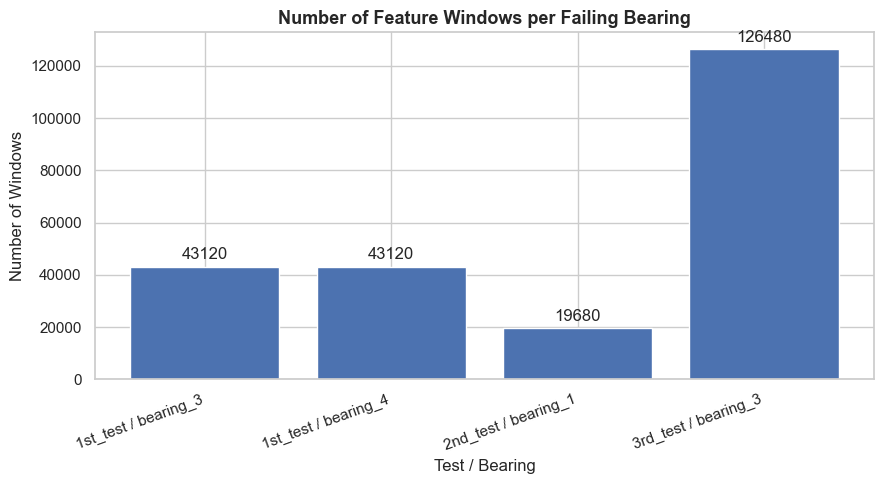

In [ ]:
# ====================================================
# Windows per Bearing/Test
# ====================================================
window_counts = (
    features_df
    .groupby(["test_set", "bearing"])
    .size()
    .reset_index(name="n_windows")
)
window_counts["label"] = window_counts["test_set"] + " / " + window_counts["bearing"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(window_counts["label"], window_counts["n_windows"], color="#4C72B0")
ax.bar_label(bars, padding=3)
ax.set_title("Number of Feature Windows per Failing Bearing")
ax.set_xlabel("Test / Bearing")
ax.set_ylabel("Number of Windows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_windows_per_bearing.png")
plt.show()

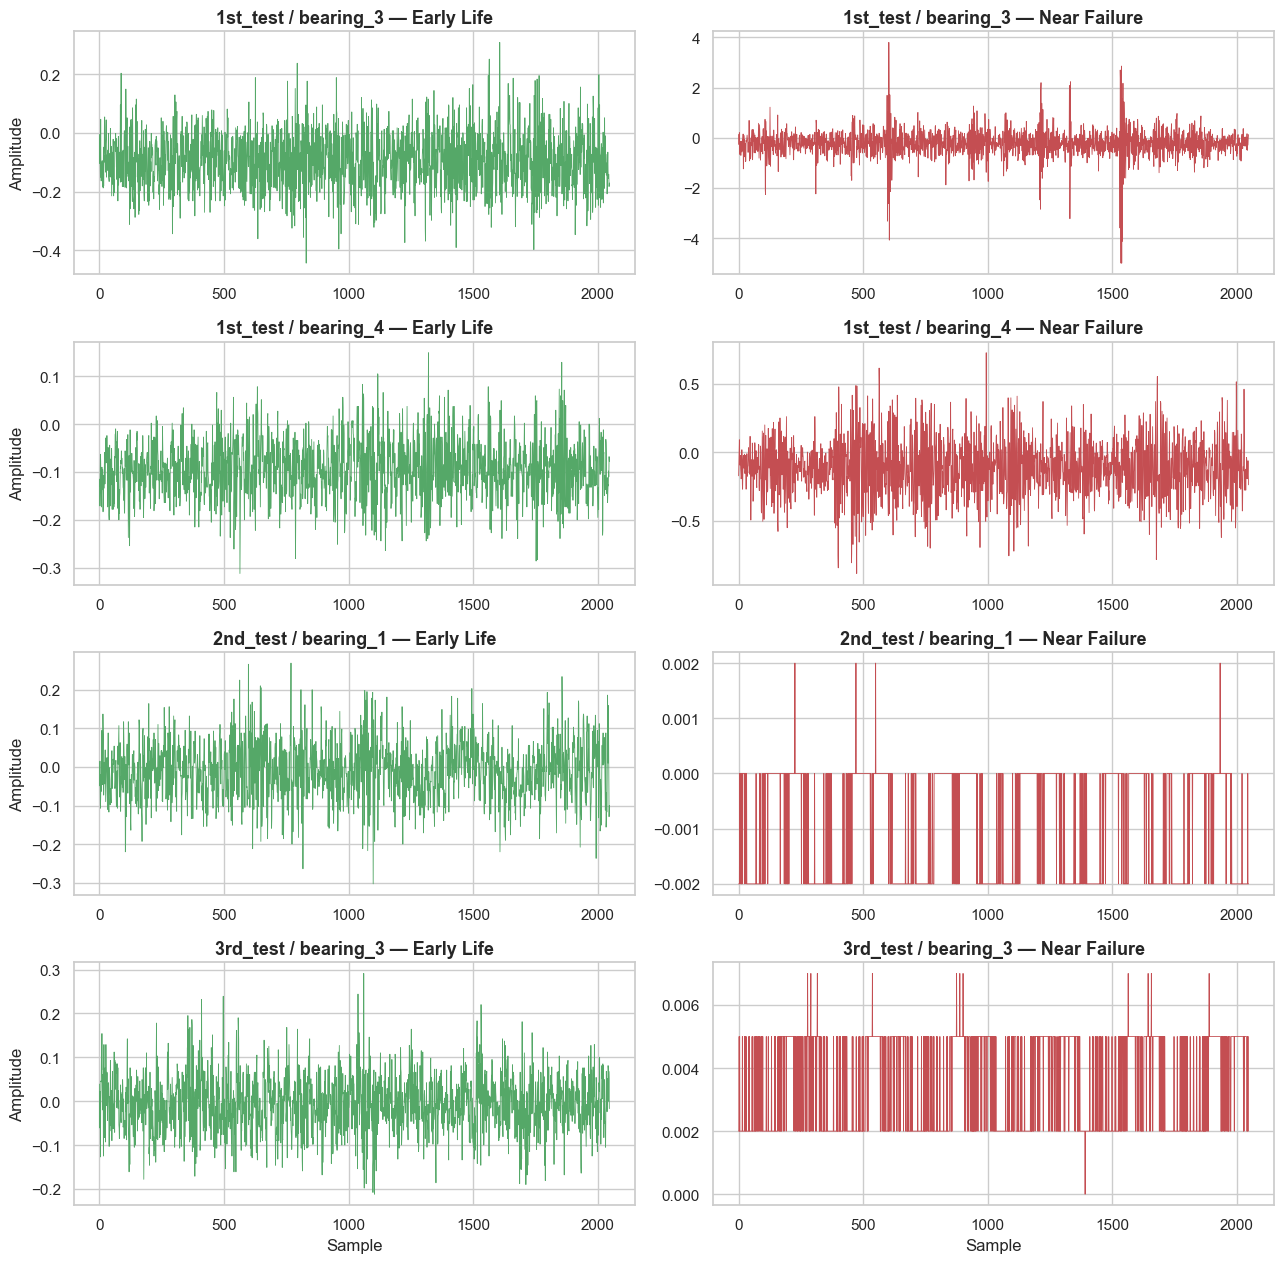

In [ ]:
# ====================================================
# Raw Waveform Comparison: Early Life vs Near Failure
# ====================================================

def load_waveform(test_name, bearing_name, file_path):
    data = pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")
    channel_index = CHANNEL_MAP[test_name][bearing_name]
    return data.iloc[:, channel_index].values


n_groups = len(FAILING_BEARING_GROUPS)
fig, axes = plt.subplots(n_groups, 2, figsize=(13, 3.2 * n_groups))
if n_groups == 1:
    axes = axes.reshape(1, -1)

for row, group in enumerate(FAILING_BEARING_GROUPS):
    test_name, bearing_name = group.test_set, group.bearing

    test_path = DATASET_PATH / test_name
    recording_files = sorted(get_recording_files(test_path), key=parse_timestamp)

    early_signal = load_waveform(test_name, bearing_name, recording_files[0])
    late_signal = load_waveform(test_name, bearing_name, recording_files[-1])

    axes[row, 0].plot(early_signal[:2048], linewidth=0.6, color="#55A868")
    axes[row, 0].set_title(f"{test_name} / {bearing_name} — Early Life")
    axes[row, 0].set_ylabel("Amplitude")

    axes[row, 1].plot(late_signal[:2048], linewidth=0.6, color="#C44E52")
    axes[row, 1].set_title(f"{test_name} / {bearing_name} — Near Failure")

for ax in axes[-1]:
    ax.set_xlabel("Sample")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_waveform_early_vs_late.png")
plt.show()

### Type 1 — Wears out slowly (1st_test bearings)
Think of it like a tire wearing down evenly. The whole surface gets rougher over time. So the signal just gets noisier and noisier everywhere, all the time.

Type 2 — Has one damaged spot (2nd_test / 3rd_test bearings)
Think of it like a tiny crack in one spot on a spinning wheel. Most of the time it's smooth. But every time that one damaged spot rotates past, it gives a little "thump." So the signal is quiet... quiet... quiet... spike... quiet... quiet... spike.

That's why they look different. Different damage = different shape.

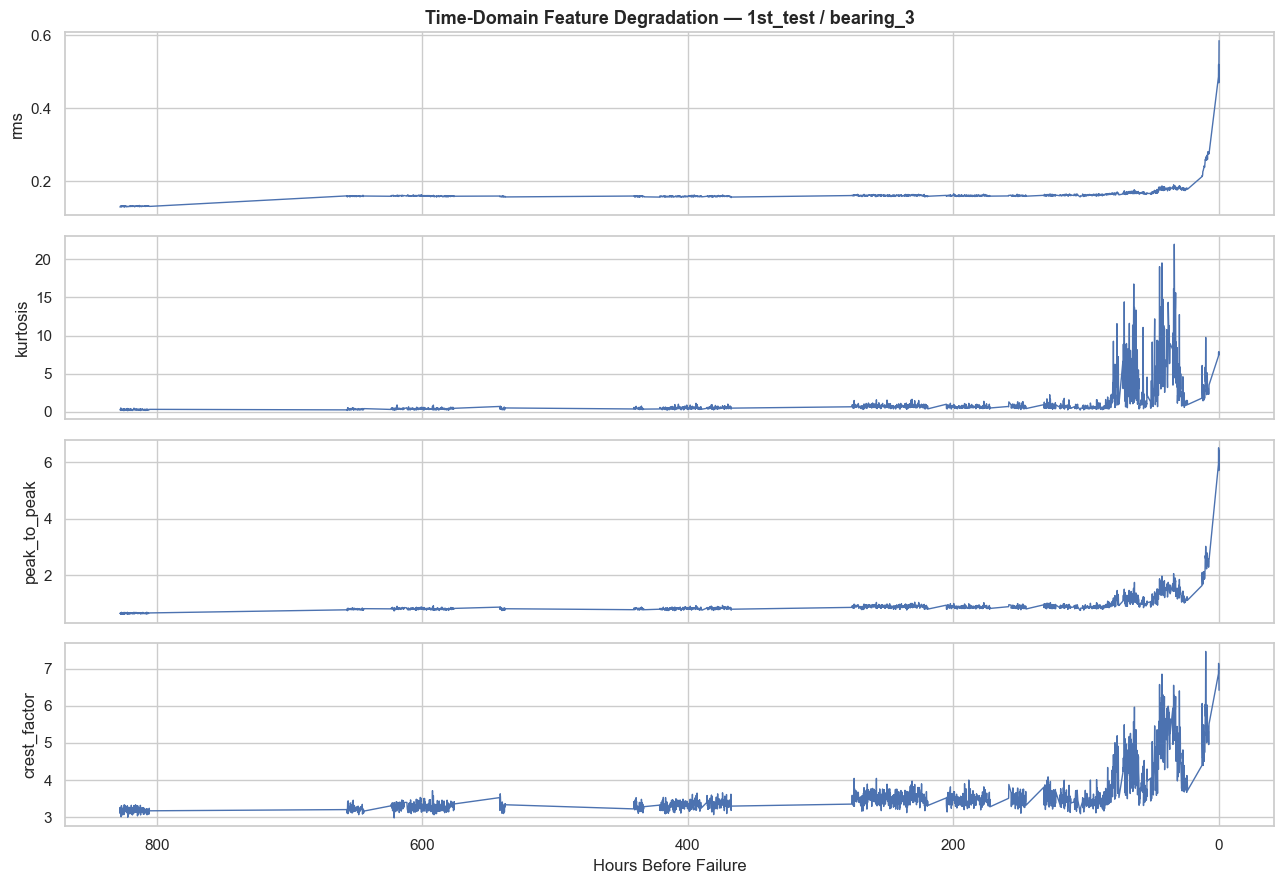

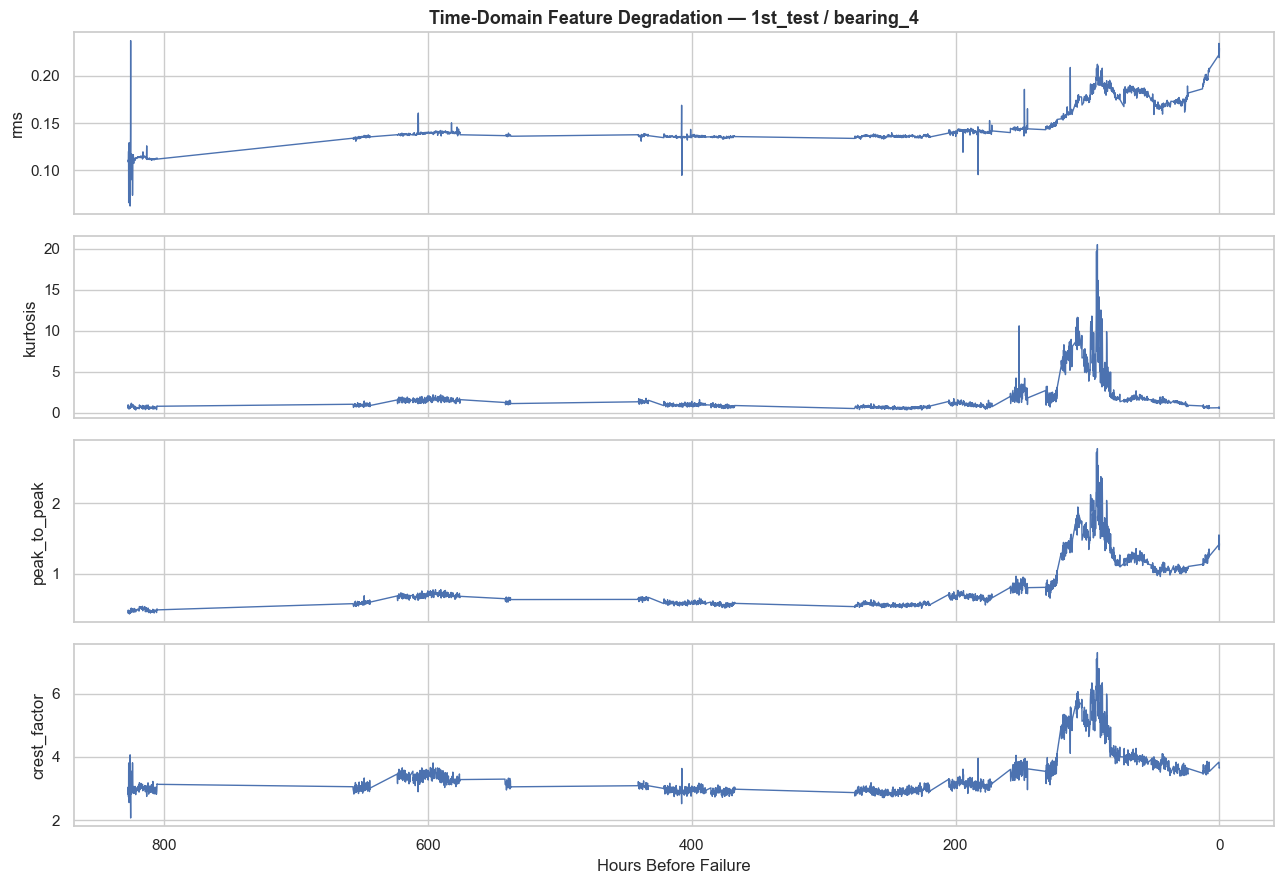

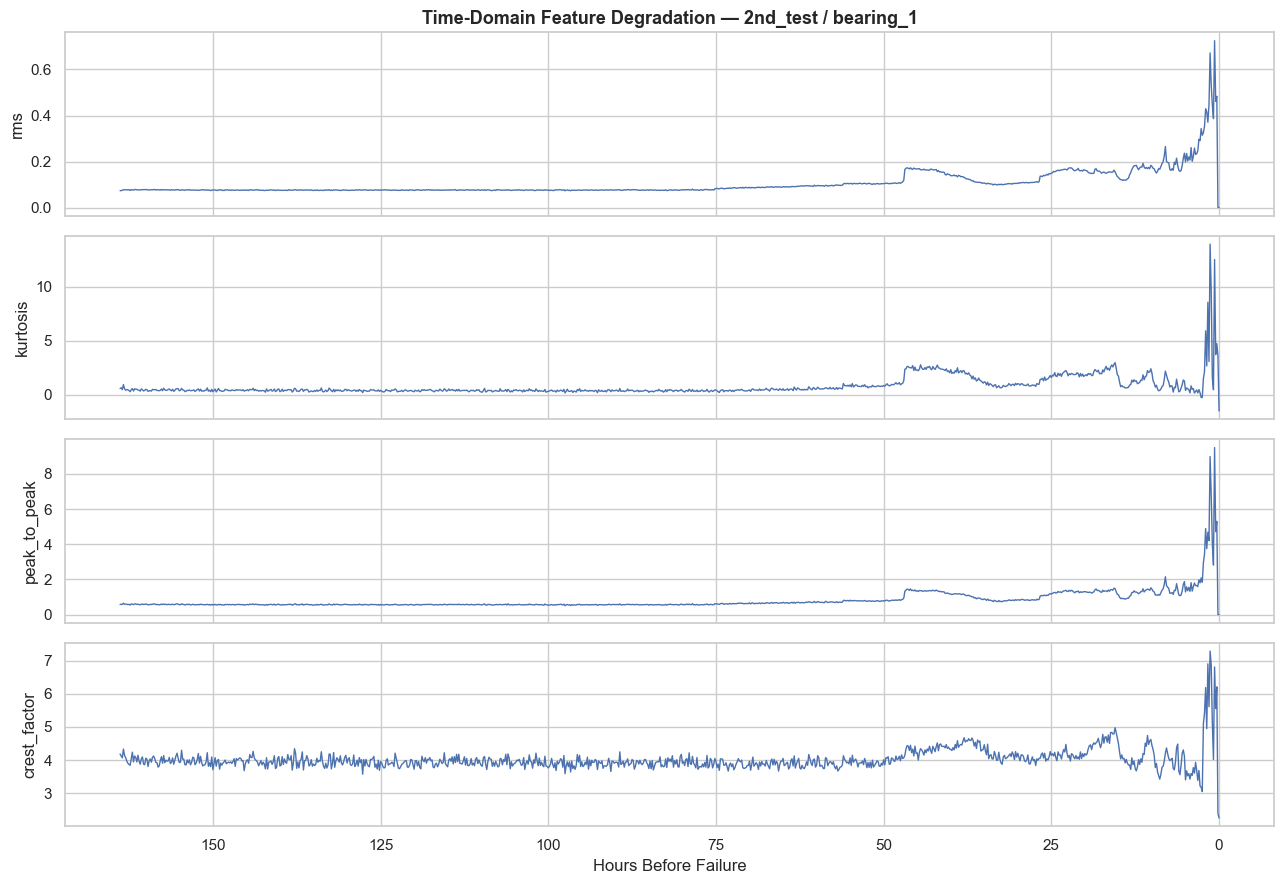

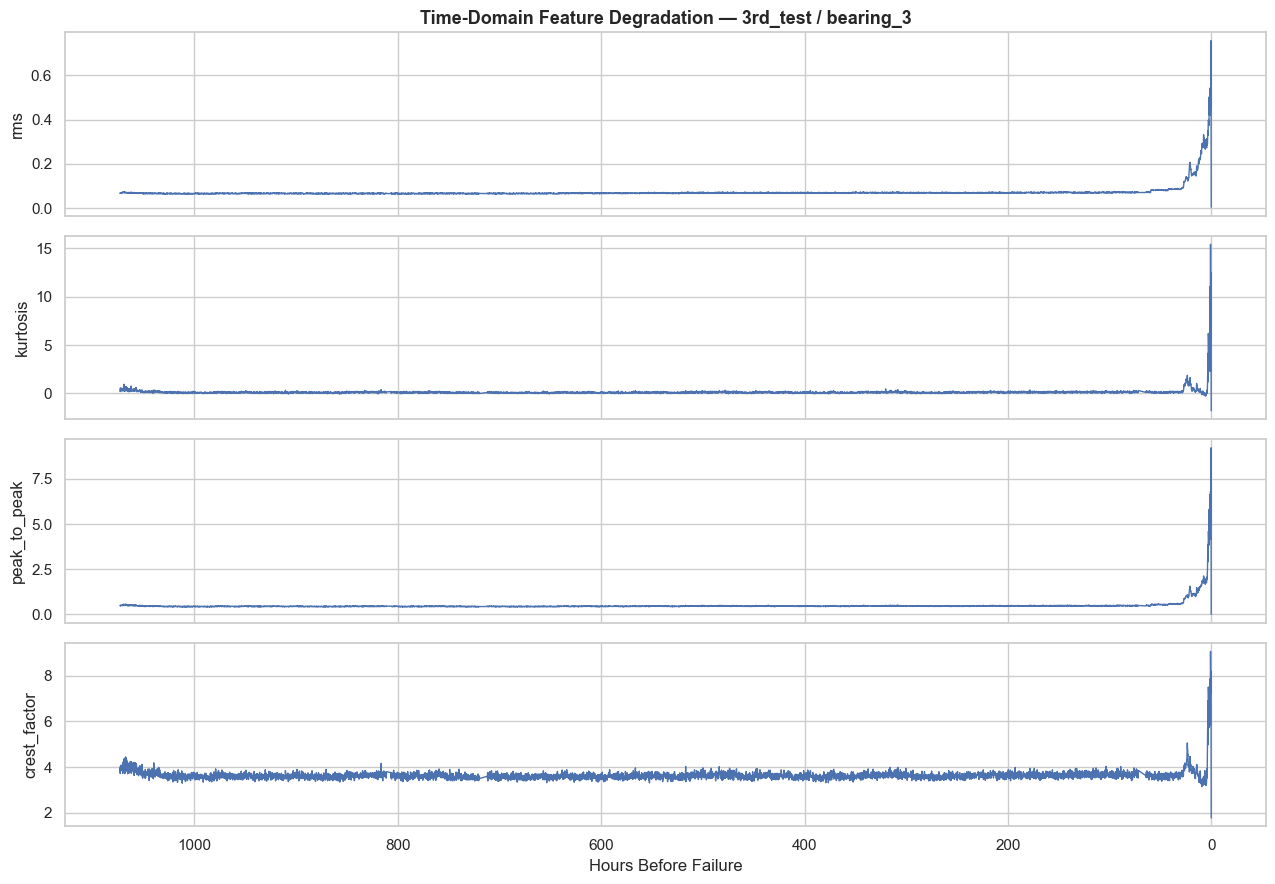

In [ ]:
# ====================================================
# Time-Domain Degradation Trends (per bearing, vs hours-to-failure)
# ====================================================
TIME_FEATURES_TO_PLOT = ["rms", "kurtosis", "peak_to_peak", "crest_factor"]

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[TIME_FEATURES_TO_PLOT]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )

    fig, axes = plt.subplots(len(TIME_FEATURES_TO_PLOT), 1, figsize=(13, 9), sharex=True)

    for ax, feature in zip(axes, TIME_FEATURES_TO_PLOT):
        ax.plot(trend["RUL_hours"], trend[feature], color="#4C72B0", linewidth=1)
        ax.set_ylabel(feature)

    # Shared x-axis: invert ONCE, after the loop. Calling invert_xaxis() once
    # per subplot above toggles the shared axis back and forth, and cancels
    # out entirely on an even number of features. Left = early life, right = failure.
    axes[0].invert_xaxis()

    axes[0].set_title(f"Time-Domain Feature Degradation — {test_name} / {bearing_name}")
    axes[-1].set_xlabel("Hours Before Failure")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_time_features_{test_name}_{bearing_name}.png")
    plt.show()

### The one non-obvious thing to mention (this impresses in a presentation):
### Kurtosis sometimes drops back down even as the bearing gets worse (you can see this in bearing_3 — busy for a while, then flat again before the end). That's not the bearing healing. It's that once the defect is big enough, impacts overlap and blend into continuous noise — statistically it starts looking "smooth" again even though it's more damaged. RMS keeps rising because energy never stops increasing; kurtosis just changes character.

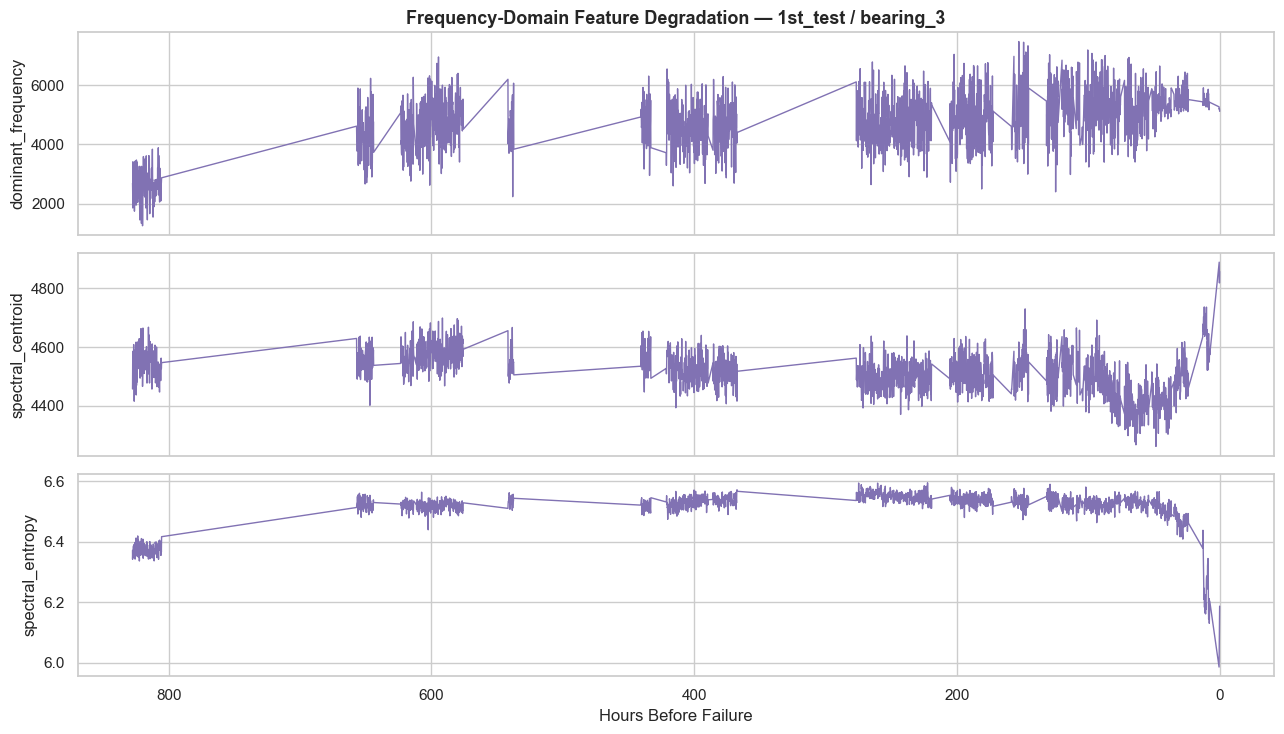

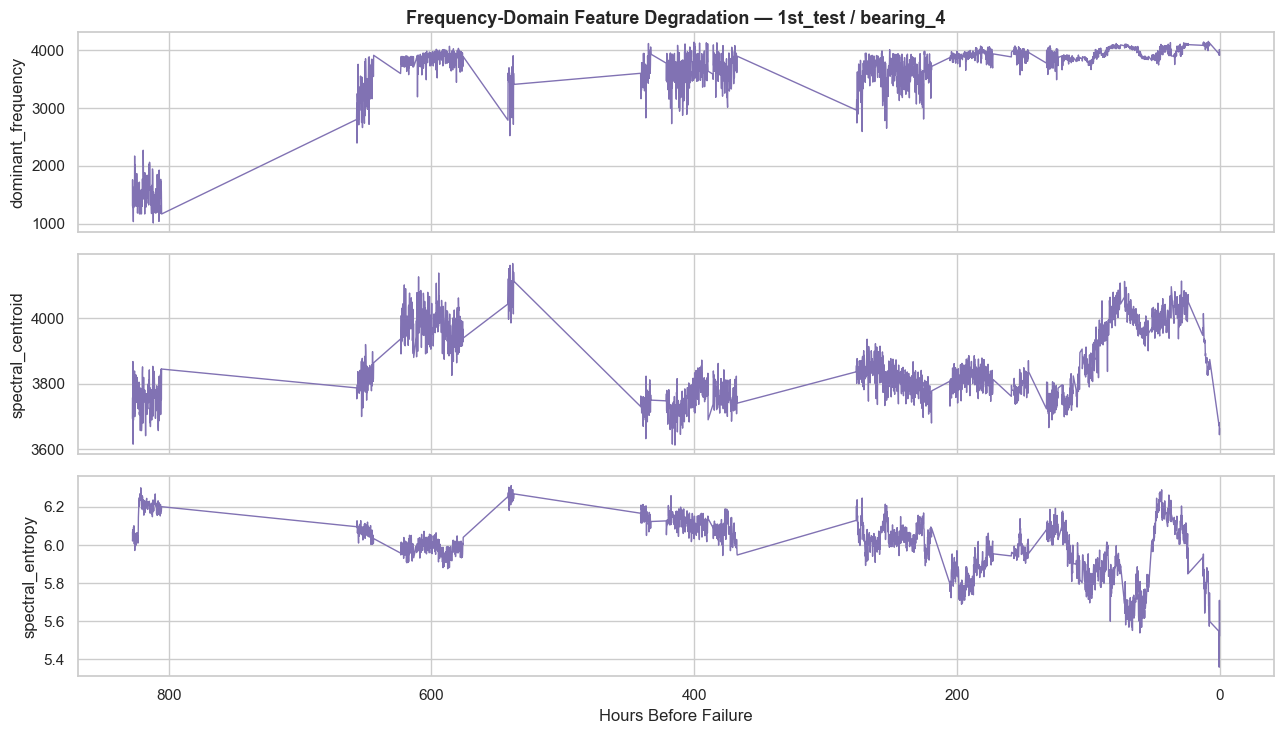

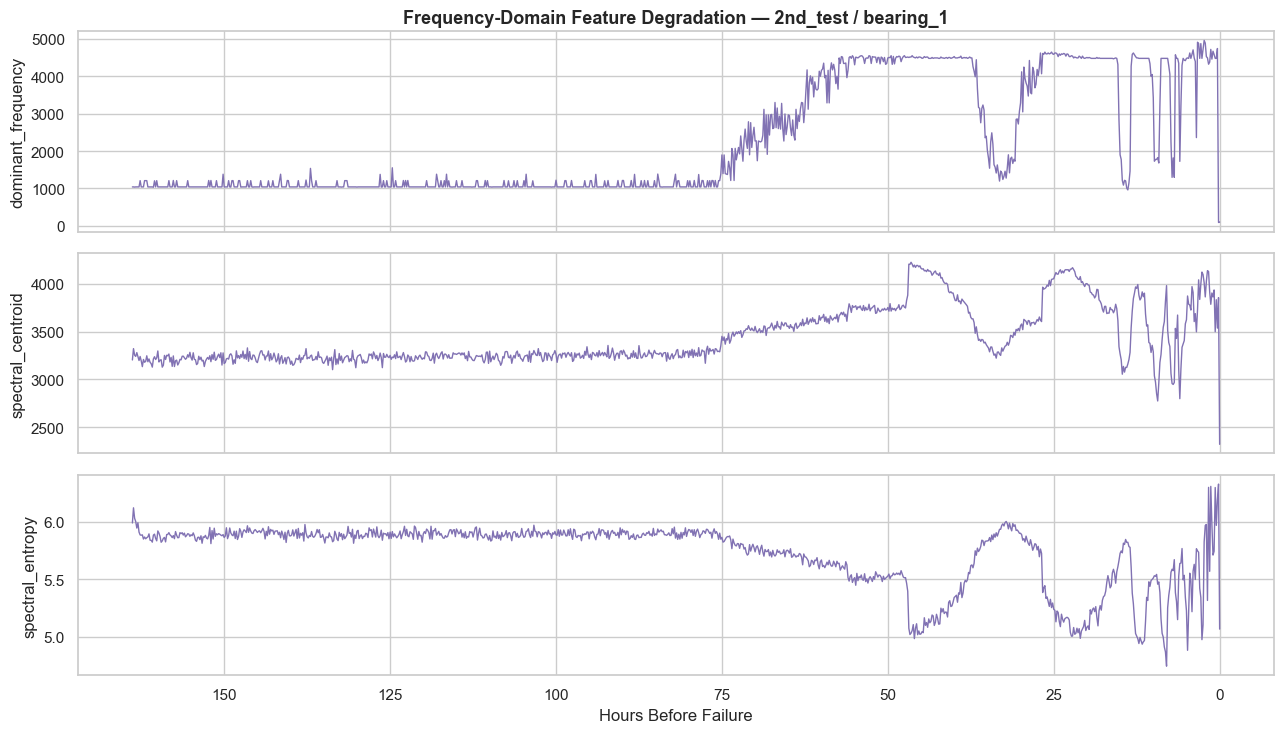

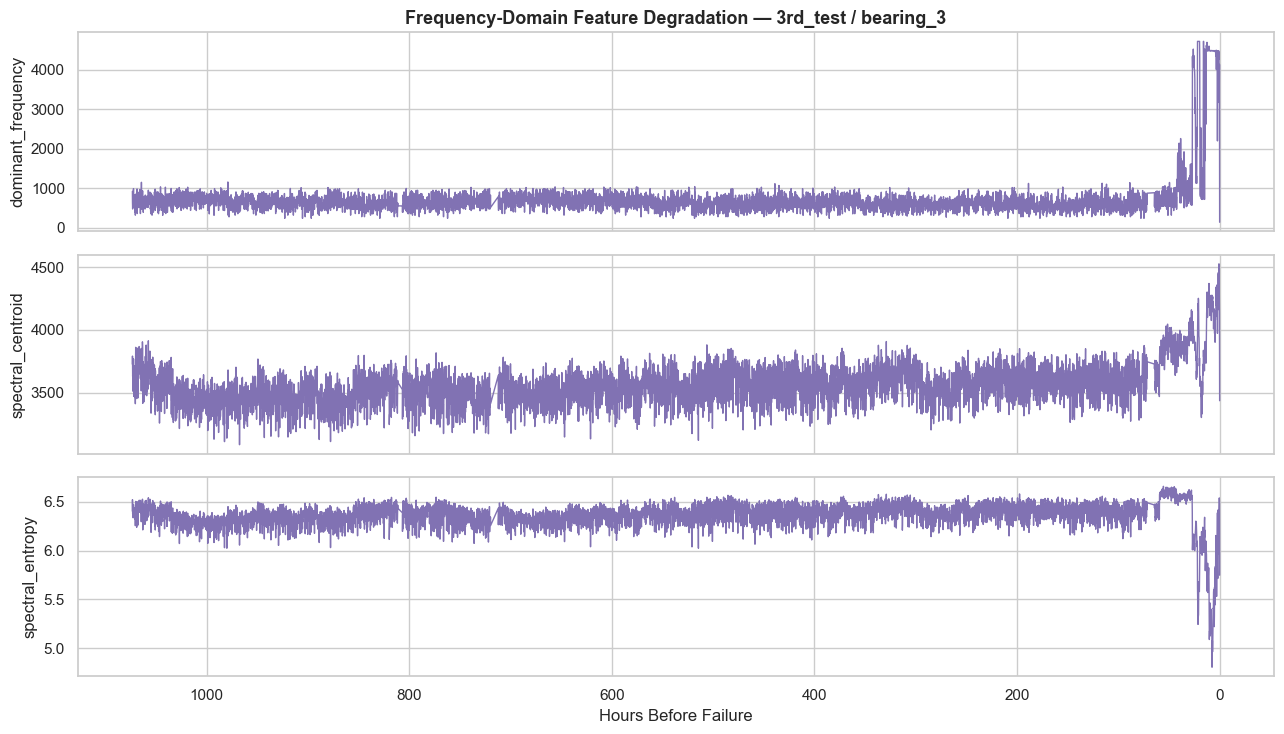

In [ ]:
# ====================================================
# Frequency-Domain Degradation Trends (per bearing, vs hours-to-failure)
# ====================================================
FREQ_FEATURES_TO_PLOT = ["dominant_frequency", "spectral_centroid", "spectral_entropy"]

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[FREQ_FEATURES_TO_PLOT]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )

    fig, axes = plt.subplots(len(FREQ_FEATURES_TO_PLOT), 1, figsize=(13, 7.5), sharex=True)

    for ax, feature in zip(axes, FREQ_FEATURES_TO_PLOT):
        ax.plot(trend["RUL_hours"], trend[feature], color="#8172B3", linewidth=1)
        ax.set_ylabel(feature)
        ax.invert_xaxis()

    axes[0].set_title(f"Frequency-Domain Feature Degradation — {test_name} / {bearing_name}")
    axes[-1].set_xlabel("Hours Before Failure")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"04_freq_features_{test_name}_{bearing_name}.png")
    plt.show()

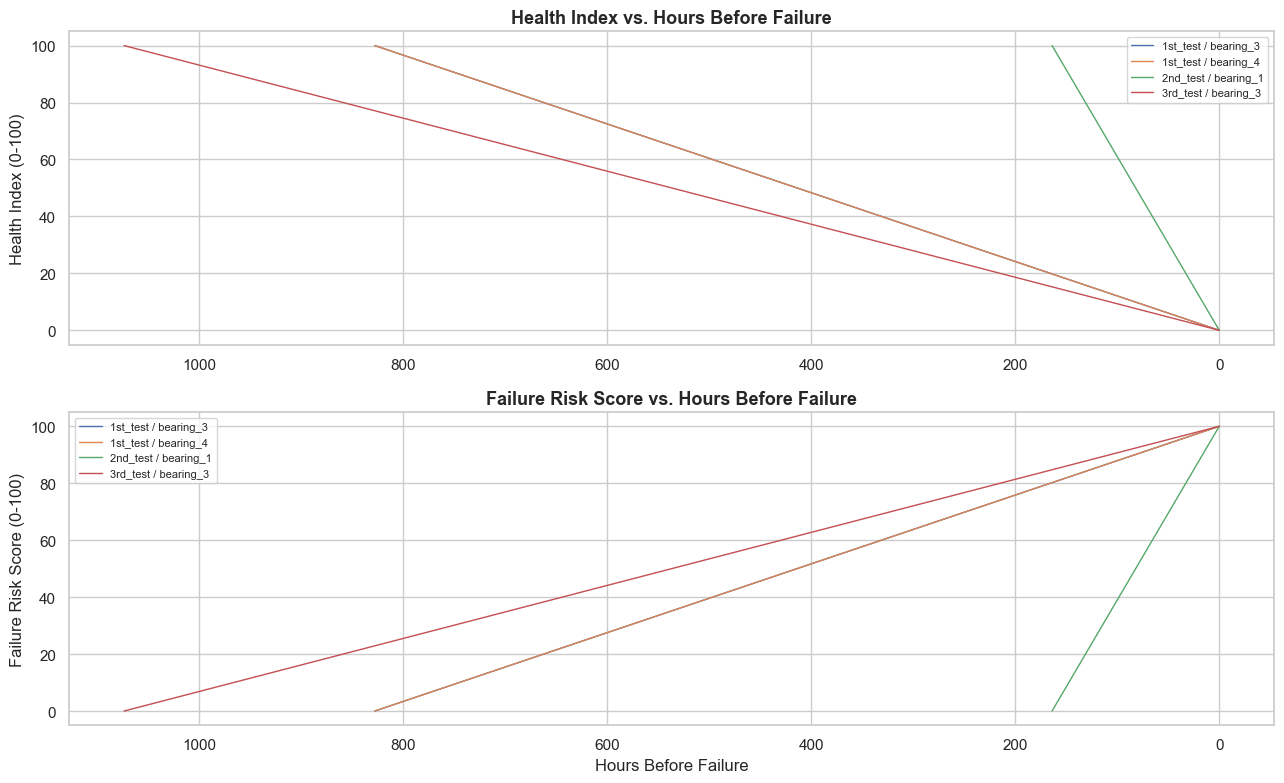

In [ ]:
# ====================================================
# Health Index / Failure Risk Score vs Hours-to-Failure (all bearings)
# ====================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[["health_index", "failure_risk_score"]]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )
    label = f"{test_name} / {bearing_name}"

    axes[0].plot(trend["RUL_hours"], trend["health_index"], label=label, linewidth=1)
    axes[1].plot(trend["RUL_hours"], trend["failure_risk_score"], label=label, linewidth=1)

axes[0].set_title("Health Index vs. Hours Before Failure")
axes[0].set_ylabel("Health Index (0-100)")
axes[0].invert_xaxis()
axes[0].legend(fontsize=8)

axes[1].set_title("Failure Risk Score vs. Hours Before Failure")
axes[1].set_ylabel("Failure Risk Score (0-100)")
axes[1].set_xlabel("Hours Before Failure")
axes[1].invert_xaxis()
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_health_index_failure_risk.png")
plt.show()

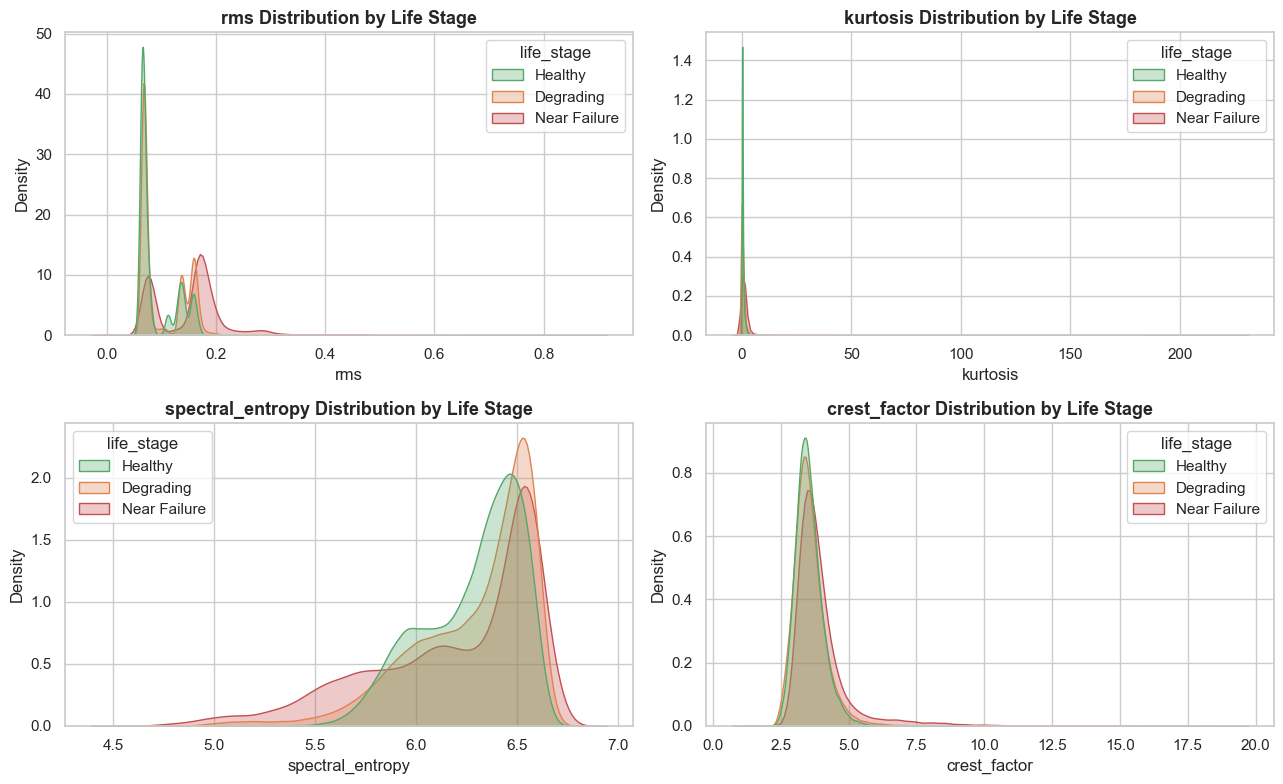

In [ ]:
# ====================================================
# Distribution Shift Across Life Stages
# ====================================================
DIST_FEATURES = ["rms", "kurtosis", "spectral_entropy", "crest_factor"]

features_df["life_stage"] = np.select(
    [features_df["RUL_fraction"] > 0.7, features_df["RUL_fraction"] < 0.1],
    ["Healthy", "Near Failure"],
    default="Degrading"
)

palette = {"Healthy": "#55A868", "Degrading": "#DD8452", "Near Failure": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, feature in zip(axes, DIST_FEATURES):
    sns.kdeplot(
        data=features_df,
        x=feature,
        hue="life_stage",
        hue_order=["Healthy", "Degrading", "Near Failure"],
        palette=palette,
        fill=True,
        alpha=0.3,
        common_norm=False,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution by Life Stage")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_feature_distributions_life_stage.png")
plt.show()

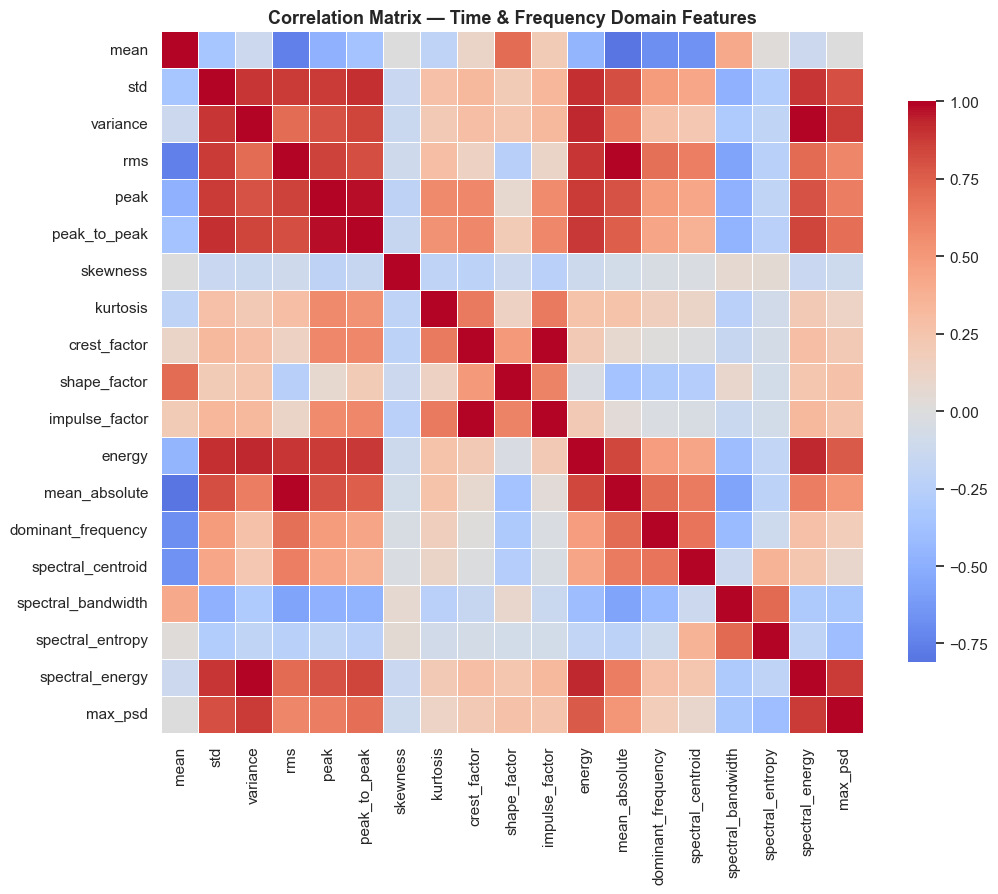

In [ ]:
# ====================================================
# Correlation Matrix — Time & Frequency Domain Features
# ====================================================
NUMERIC_FEATURE_COLS = [
    "mean", "std", "variance", "rms", "peak", "peak_to_peak",
    "skewness", "kurtosis", "crest_factor", "shape_factor",
    "impulse_factor", "energy", "mean_absolute",
    "dominant_frequency", "spectral_centroid", "spectral_bandwidth",
    "spectral_entropy", "spectral_energy", "max_psd"
]

corr_matrix = features_df[NUMERIC_FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Correlation Matrix — Time & Frequency Domain Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_feature_correlation_heatmap.png")
plt.show()

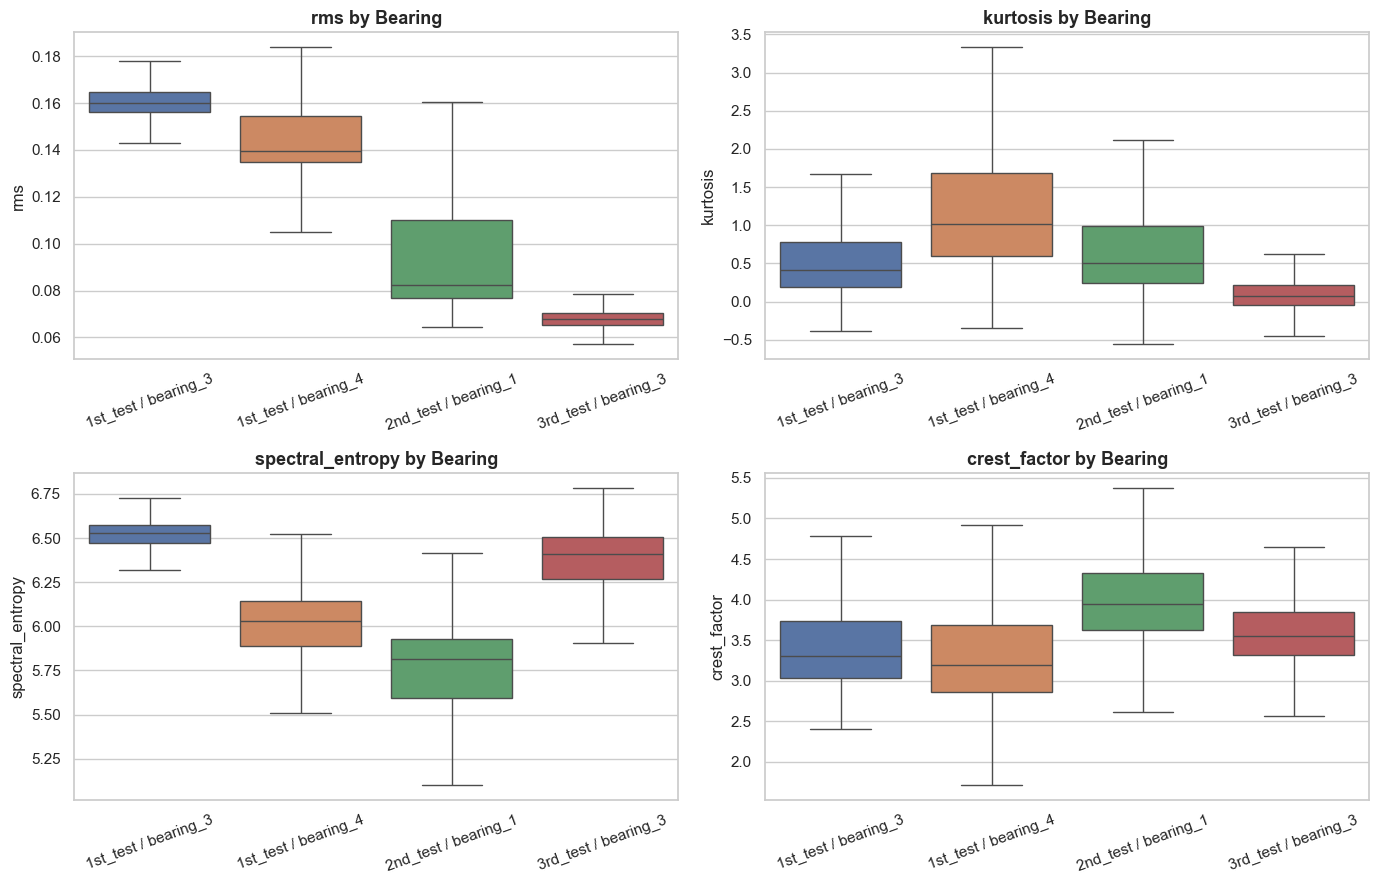

In [ ]:
# ====================================================
# Feature Spread by Bearing
# ====================================================
features_df["group"] = features_df["test_set"] + " / " + features_df["bearing"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, feature in zip(axes, DIST_FEATURES):
    sns.boxplot(
        data=features_df,
        x="group",
        y=feature,
        hue="group",
        palette="deep",
        legend=False,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f"{feature} by Bearing")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_feature_boxplots_by_bearing.png")
plt.show()

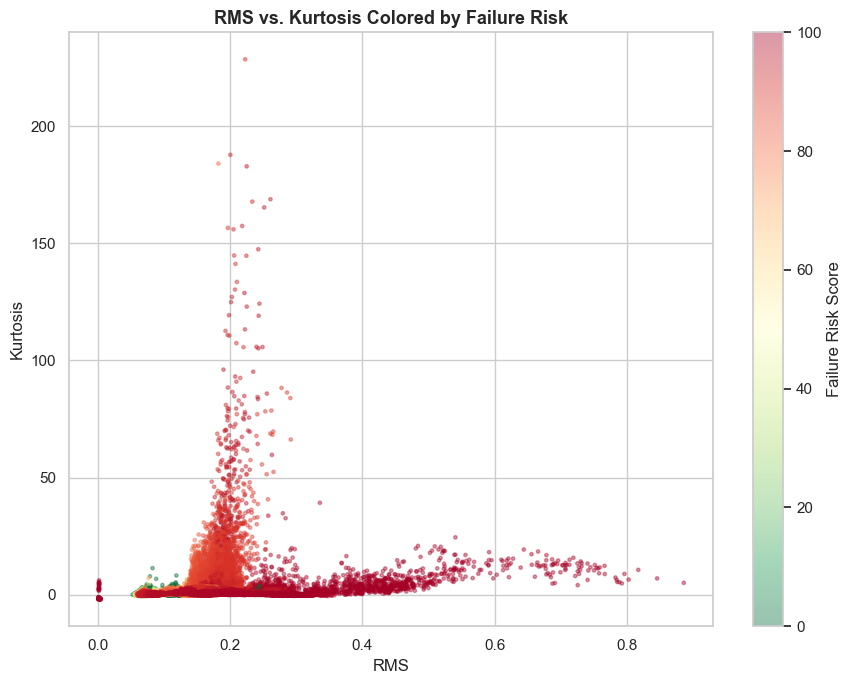

In [ ]:
# ====================================================
# RMS vs Kurtosis Scatter — Failure Progression
# ====================================================
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    features_df["rms"],
    features_df["kurtosis"],
    c=features_df["failure_risk_score"],
    cmap="RdYlGn_r",
    s=6,
    alpha=0.4
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Failure Risk Score")
ax.set_xlabel("RMS")
ax.set_ylabel("Kurtosis")
ax.set_title("RMS vs. Kurtosis Colored by Failure Risk")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_rms_vs_kurtosis_risk.png")
plt.show()

In [ ]:
# ====================================================
# Summary Statistics Table
# ====================================================
summary_stats = (
    features_df
    .groupby(["test_set", "bearing"])[NUMERIC_FEATURE_COLS]
    .agg(["mean", "std", "min", "max"])
)
summary_stats

mean                                     std  \
                        mean       std       min       max      mean   
test_set bearing                                                       
1st_test bearing_3 -0.112761  0.010216 -0.243764  0.537065  0.115125   
         bearing_4 -0.112849  0.008290 -0.234787  0.017646  0.091390   
2nd_test bearing_1 -0.001943  0.002810 -0.037029  0.027100  0.105967   
3rd_test bearing_3 -0.002073  0.003780 -0.360870  0.411486  0.072243   

                                                  variance            ...  \
                         std       min       max      mean       std  ...   
test_set bearing                                                      ...   
1st_test bearing_3  0.024332  0.079160  0.778452  0.013846  0.012213  ...   
         bearing_4  0.029332  0.048812  0.265877  0.009212  0.006566  ...   
2nd_test bearing_1  0.058358  0.000879  0.765265  0.014634  0.030573  ...   
3rd_test bearing_3  0.030792  0.001490  0.854622  0.006167  0.014339  ...   

                   spectral_entropy           spectral_energy            \
                                min       max            mean       std   
test_set bearing                                                          
1st_test bearing_3         5.189735  6.738315        0.000173  0.000157   
         bearing_4         4.931278  6.594852        0.000115  0.000084   
2nd_test bearing_1         4.552171  6.620348        0.000181  0.000382   
3rd_test bearing_3         4.623731  6.782413        0.000076  0.000173   

                                             max_psd                          \
                             min       max      mean       std           min   
test_set bearing                                                               
1st_test bearing_3  7.640319e-05  0.008378  0.000008  0.000016  2.803596e-06   
         bearing_4  2.719083e-05  0.000950  0.000010  0.000010  1.456928e-06   
2nd_test bearing_1  8.931479e-09  0.007450  0.000020  0.000038  5.245115e-10   
3rd_test bearing_3  2.477484e-08  0.007881  0.000007  0.000021  2.950198e-09   

                              
                         max  
test_set bearing              
1st_test bearing_3  0.001218  
         bearing_4  0.000129  
2nd_test bearing_1  0.000705  
3rd_test bearing_3  0.000639  

[4 rows x 76 columns]

### 1. The "Golden Age" (160h down to ~40h)
* **Stable Baseline:** During the vast majority of its operational life, the bearing runs smoothly. The background is dark purple, indicating minimal energy distribution across the frequency spectrum.
* **Operational Signatures:** The horizontal faint lines at low frequencies (e.g., around $33.3\text{ Hz}$ and its multiples $66.6\text{ Hz}$, $100\text{ Hz}$) represent normal rotational mechanics: shaft rotation speed and gear meshing. These are expected "heartbeat" signals, not signs of damage.

### 2. The Micro-Cracking / Incipience Phase (~40h down to ~15h)
* **Subtle Energy Shifts:** Long before total breakdown, you begin to see faint, static horizontal bands at $235\text{ Hz}$ and $470\text{ Hz}$ standardizing. 
* **Physical Phenomenon:** A micro-spall or sub-surface fatigue crack forms on the outer raceway. Every time a rolling element passes over this defect, it triggers a tiny micro-impact at a rate of $235.3\text{ Hz}$ (BPFO). At this stage, the damage is localized and invisible to the naked eye.

### 3. Accelerated Degradation (~15h down to ~2h)
* **Harmonic Multiplication:** As the outer race pit enlarges, impact forces grow stronger. The fundamental frequency ($235\text{ Hz}$) brightens into a vivid yellow, and its higher order harmonics ($2\times \approx 470\text{ Hz}$, $3\times \approx 700\text{ Hz}$, $4\times \approx 940\text{ Hz}$) emerge clearly.
* **Sideband Generation:** Micro-fluctuations around these main harmonic lines start appearing. These sidebands ($BPFO \pm \text{Shaft Speed}$) occur because the impact amplitude gets modulated as the load zone shifts relative to the rotating shaft.

### 4. Terminal Breakdown & Failure (Last 2 Hours to 0h)
* **Broadband Smearing:** Right near $RUL = 0$, the clean, isolated frequency horizontal lines collapse into an explosive vertical strip of bright yellow/white across *all* frequencies ($0\text{ Hz} - 1000\text{ Hz}$).
* **Physical Destruction:** Pitting has progressed to spalling, metal flaking, and severe surface disintegration. The rolling elements are no longer striking a single defect site cleanly; they are sliding and grinding against severe surface roughing. This creates random, high-amplitude impact noise (broadband resonance) right before seizure or catastrophic mechanical failure.

---

### Machine Learning Narrative Takeaways

* **Feature Selection Justification:** It proves why tracking raw RMS or overall signal energy alone is insufficient. The fault shows up at specific frequencies ($235\text{ Hz}$) tens of hours *before* total energy spikes across the entire band.
* **RUL Target Definition:** The transition around 15–20 hours provides a clear physical milestone for defining health stages (e.g., classifying states into Healthy, Degrading, and Critical).

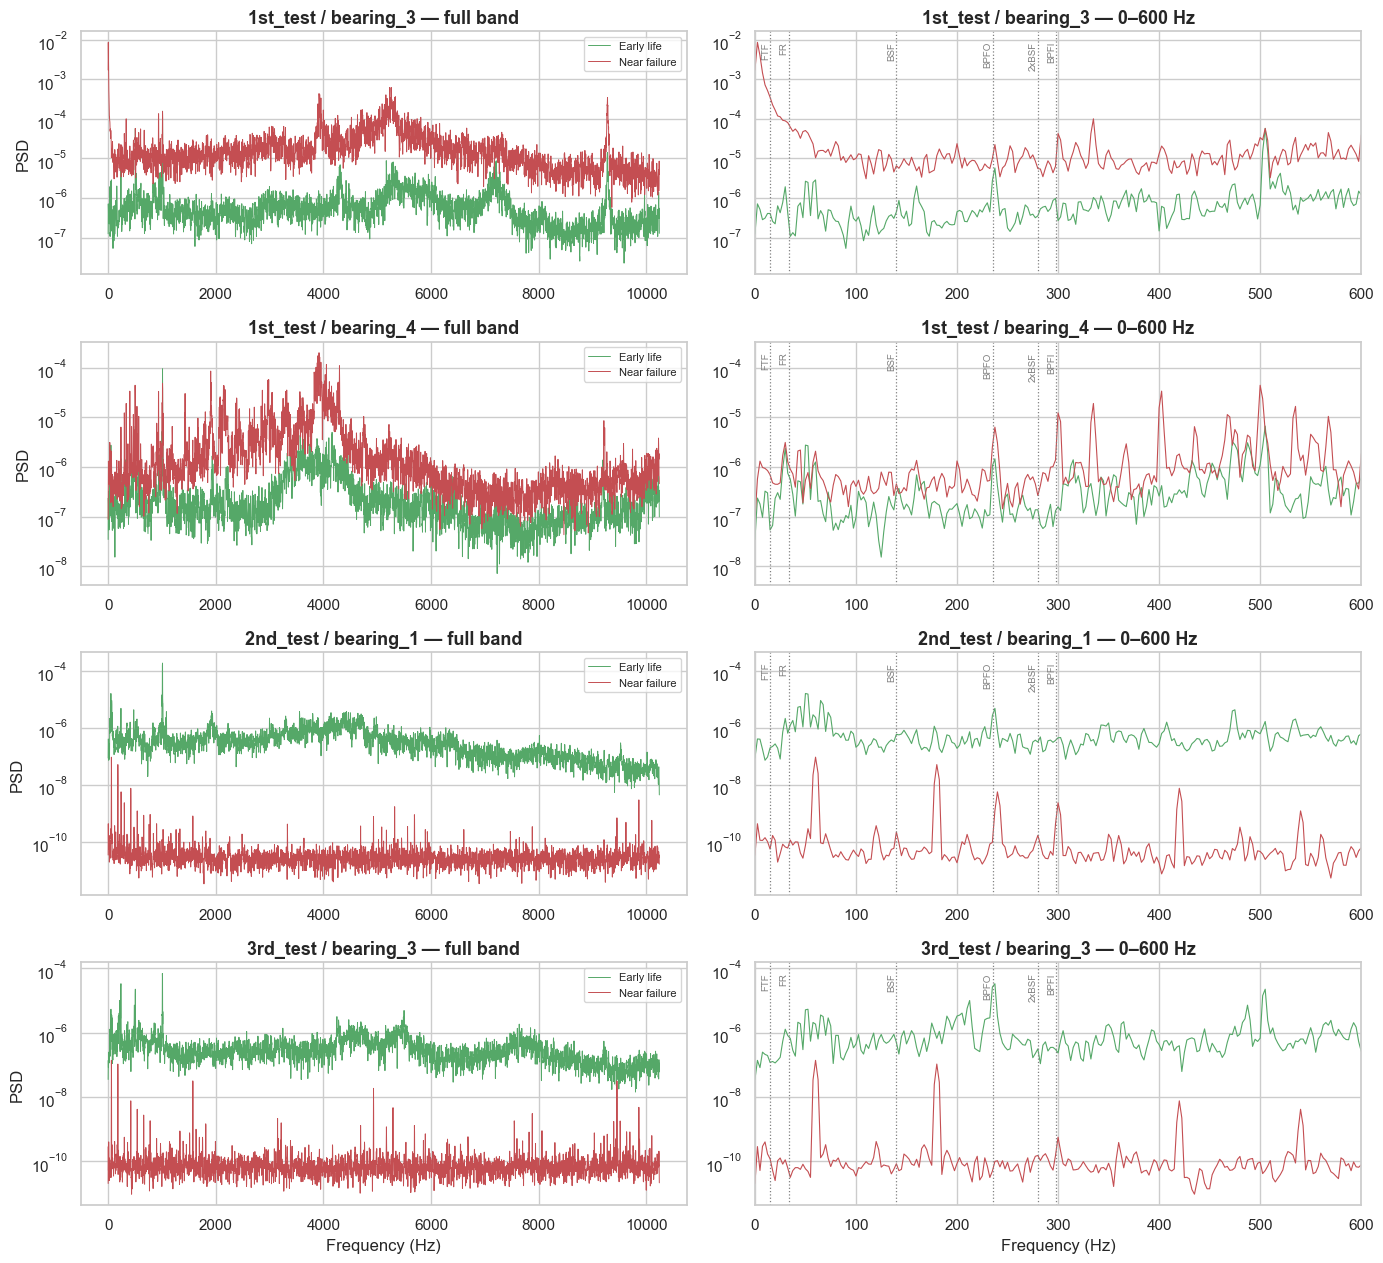

In [55]:
# ====================================================
# 10 — PSD: Early Life vs Near Failure
# ====================================================

PLOT_MARKERS = {**DEFECT_FREQS, "FR": round(FR, 1), "2xBSF": 2 * DEFECT_FREQS["BSF"]}

n_groups = len(FAILING_BEARING_GROUPS)
fig, axes = plt.subplots(n_groups, 2, figsize=(14, 3.2 * n_groups))
if n_groups == 1:
    axes = axes.reshape(1, -1)

for row, group in enumerate(FAILING_BEARING_GROUPS):
    key = (group.test_set, group.bearing)
    freqs, psd = PSD_HISTORY[key]["freqs"], PSD_HISTORY[key]["psd"]

    axes[row, 0].semilogy(freqs, psd[0],  lw=0.7, color="#55A868", label="Early life")
    axes[row, 0].semilogy(freqs, psd[-1], lw=0.7, color="#C44E52", label="Near failure")
    axes[row, 0].set_ylabel("PSD")
    axes[row, 0].set_title(f"{key[0]} / {key[1]} — full band")
    axes[row, 0].legend(fontsize=8)

    axes[row, 1].semilogy(freqs, psd[0],  lw=0.8, color="#55A868")
    axes[row, 1].semilogy(freqs, psd[-1], lw=0.8, color="#C44E52")
    axes[row, 1].set_xlim(0, 600)
    axes[row, 1].set_title(f"{key[0]} / {key[1]} — 0–600 Hz")

    for name, f0 in PLOT_MARKERS.items():
        axes[row, 1].axvline(f0, color="gray", ls=":", lw=0.9)
        axes[row, 1].annotate(name, xy=(f0, 0.96), xycoords=("data", "axes fraction"),
                              rotation=90, fontsize=7, color="gray", ha="right", va="top")

for ax in axes[-1]:
    ax.set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_psd_early_vs_late.png", dpi=120)
plt.show()

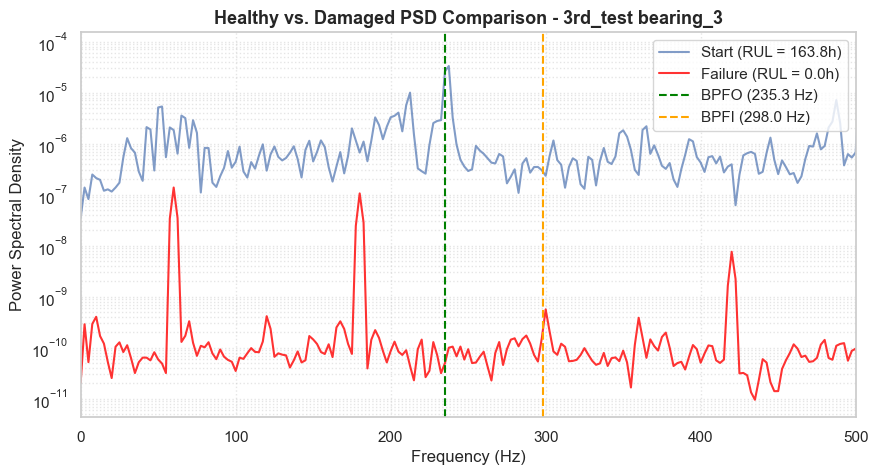

In [56]:
plt.figure(figsize=(10, 5))

# Plot first snapshot (Healthy)
plt.plot(freqs, psd[0], label=f"Start (RUL = {rul[0]:.1f}h)", alpha=0.7)

# Plot last snapshot (Failed)
plt.plot(freqs, psd[-1], label=f"Failure (RUL = {rul[-1]:.1f}h)", alpha=0.8, color="red")

# Annotate Bearing Defect Frequencies printed in your output
plt.axvline(x=235.3, color="green", linestyle="--", label="BPFO (235.3 Hz)")
plt.axvline(x=298.0, color="orange", linestyle="--", label="BPFI (298.0 Hz)")

plt.xlim(0, 500)  # Zoom in on primary defect range
plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(f"Healthy vs. Damaged PSD Comparison - {key[0]} {key[1]}")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()

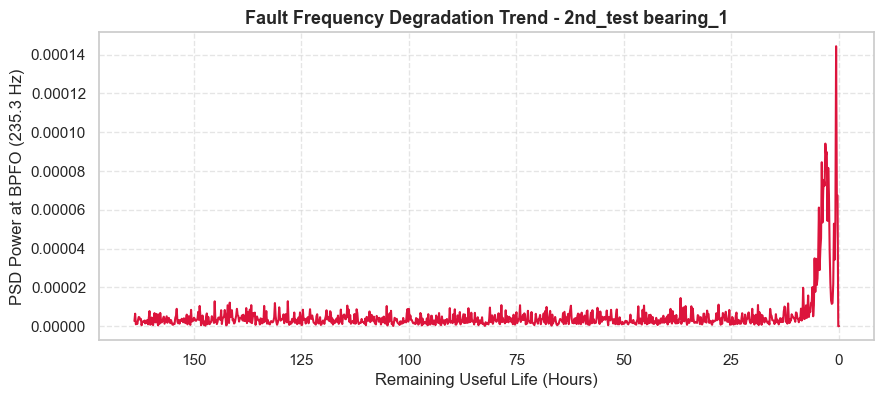

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Select the test bearing entry explicitly
key = ("2nd_test", "bearing_1")  # Or ("1st_test", "bearing_3"), etc.
entry = PSD_HISTORY[key]

# Extract freqs, psd, and RUL directly from the target dictionary entry
freqs = entry["freqs"]
psd = entry["psd"]          # Shape: (984, 4097)
rul = entry["rul_hours"]    # Shape: (984,)

# Find index nearest to the BPFO fault frequency (~235.3 Hz)
bpfo_idx = np.argmin(np.abs(freqs - 235.3))

plt.figure(figsize=(10, 4))
plt.plot(rul, psd[:, bpfo_idx], color="crimson")
plt.gca().invert_xaxis()
plt.xlabel("Remaining Useful Life (Hours)")
plt.ylabel("PSD Power at BPFO (235.3 Hz)")
plt.title(f"Fault Frequency Degradation Trend - {key[0]} {key[1]}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [8]:
# ====================================================
# Convert filename into timestamp
# ====================================================

def parse_timestamp(file_path):
    return pd.to_datetime(
        file_path.name,
        format="%Y.%m.%d.%H.%M.%S",
        errors="coerce"
    )


print(parse_timestamp(sample_file))

2003-10-22 12:06:24


In [9]:
def create_windows(signal, window_size=1024):
    """
    Split a signal into non-overlapping windows.

    Parameters
    ----------
    signal : array-like
        Raw vibration signal.

    window_size : int
        Number of samples in each window.

    Returns
    -------
    windows : ndarray
        Shape = (number_of_windows, window_size)
    """
    
    signal = np.asarray(signal)
    
    n_windows = len(signal) // window_size
    
    trimmed_length = n_windows * window_size
    
    trimmed_signal = signal[:trimmed_length]
    
    windows = trimmed_signal.reshape(
        n_windows,
        window_size
    )
    
    return windows

In [10]:
signal = sample.iloc[:, CHANNEL_MAP["1st_test"]["bearing_3"]].values

windows = create_windows(
    signal,
    window_size=1024
)

print("Original samples :", len(signal))
print("Window shape     :", windows.shape)
print("Number of windows:", len(windows))

Original samples : 20480
Window shape     : (20, 1024)
Number of windows: 20


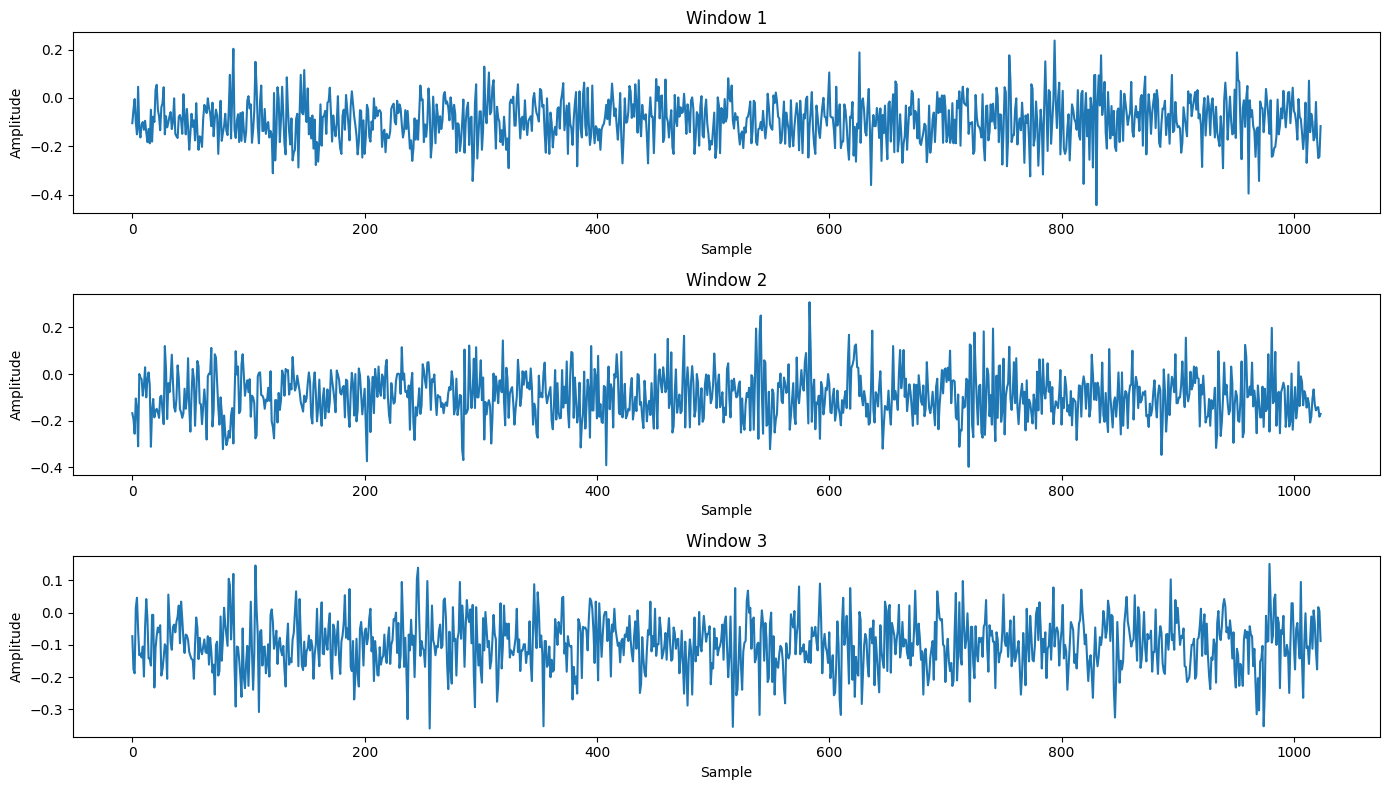

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

for i, ax in enumerate(axes):
    ax.plot(windows[i])
    ax.set_title(f"Window {i + 1}")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [12]:
def extract_time_features(x):
    """
    Extract time-domain features from one vibration window.
    """
    
    x = np.asarray(x)
    
    abs_x = np.abs(x)
    
    rms = np.sqrt(np.mean(x ** 2))
    
    peak = np.max(abs_x)
    
    mean_abs = np.mean(abs_x)
    
    features = {
        "mean": np.mean(x),
        "std": np.std(x),
        "variance": np.var(x),
        "rms": rms,
        "peak": peak,
        "peak_to_peak": np.ptp(x),
        "skewness": skew(x),
        "kurtosis": kurtosis(x),
        "crest_factor": peak / rms if rms != 0 else 0,
        "shape_factor": rms / mean_abs if mean_abs != 0 else 0,
        "impulse_factor": peak / mean_abs if mean_abs != 0 else 0,
        "energy": np.sum(x ** 2),
        "mean_absolute": mean_abs
    }
    
    return features

In [13]:
def extract_frequency_features(x, fs=20480):
    """
    Extract frequency-domain features using Welch PSD.

    fs = sampling frequency in Hz.
    """
    
    frequencies, psd = welch(
        x,
        fs=fs,
        nperseg=min(256, len(x))
    )
    
    psd_sum = np.sum(psd)
    
    if psd_sum == 0:
        psd_sum = 1e-12
    
    dominant_frequency = frequencies[np.argmax(psd)]
    
    spectral_centroid = (
        np.sum(frequencies * psd) / psd_sum
    )
    
    spectral_bandwidth = np.sqrt(
        np.sum(
            ((frequencies - spectral_centroid) ** 2) * psd
        ) / psd_sum
    )
    
    normalized_psd = psd / psd_sum
    
    spectral_entropy = -np.sum(
        normalized_psd *
        np.log2(normalized_psd + 1e-12)
    )
    
    spectral_energy = np.sum(psd)
    
    return {
        "dominant_frequency": dominant_frequency,
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "spectral_entropy": spectral_entropy,
        "spectral_energy": spectral_energy,
        "max_psd": np.max(psd)
    }

In [16]:
def extract_features(window, fs=20480):
    """
    Extract all time and frequency-domain features.
    """
    
    time_features = extract_time_features(window)
    
    frequency_features = extract_frequency_features(
        window,
        fs=fs
    )
    
    return {
        **time_features,
        **frequency_features
    }

In [17]:
WINDOW_SIZE = 1024
SAMPLING_FREQUENCY = 20480

all_rows = []

for test_name, failed_bearings in FAILED_BEARINGS.items():
    
    test_path = DATASET_PATH / test_name
    
    recording_files = get_recording_files(test_path)
    
    recording_files = sorted(
        recording_files,
        key=parse_timestamp
    )
    
    print(f"\nProcessing {test_name}...")
    print(f"Total recordings: {len(recording_files)}")
    
    for recording_index, file_path in enumerate(recording_files):
        
        timestamp = parse_timestamp(file_path)
        
        data = pd.read_csv(
            file_path,
            sep=r"\s+",
            header=None,
            engine="python"
        )
        
        for bearing_name in failed_bearings:
            
            channel_index = CHANNEL_MAP[test_name][bearing_name]
            
            signal = data.iloc[:, channel_index].values
            
            windows = create_windows(
                signal,
                window_size=WINDOW_SIZE
            )
            
            for window_index, window in enumerate(windows):
                
                feature_row = extract_features(
                    window,
                    fs=SAMPLING_FREQUENCY
                )
                
                feature_row["test_set"] = test_name
                feature_row["bearing"] = bearing_name
                feature_row["recording_index"] = recording_index
                feature_row["window_index"] = window_index
                feature_row["timestamp"] = timestamp
                
                all_rows.append(feature_row)
    
    print(f"Finished {test_name}")

features_df = pd.DataFrame(all_rows)

print("\nFinal shape:", features_df.shape)


Processing 1st_test...
Total recordings: 2156
Finished 1st_test

Processing 2nd_test...
Total recordings: 984
Finished 2nd_test

Processing 3rd_test...
Total recordings: 6324
Finished 3rd_test

Final shape: (232400, 24)


In [18]:
features = extract_features(windows[0])

pd.DataFrame([features])

,mean,std,variance,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,impulse_factor,energy,mean_absolute,dominant_frequency,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_energy,max_psd
0,0.003452,0.001522,0.000002,0.003773,0.007,0.005,0.131693,-1.860826,1.855426,1.092861,2.027723,0.014575,0.003452,160.0,3499.675103,3541.730233,5.717749,2.633541e-08,3.633082e-09


In [20]:
features_df = features_df.sort_values(
    by=[
        "test_set",
        "bearing",
        "timestamp",
        "window_index"
    ]
).reset_index(drop=True)

features_df.head()

,mean,std,variance,rms,peak,peak_to_peak,skewness,kurtosis,crest_factor,shape_factor,...,spectral_centroid,spectral_bandwidth,spectral_entropy,spectral_energy,max_psd,test_set,bearing,recording_index,window_index,timestamp
0,-0.092337,0.089429,0.007997,0.128544,0.444,0.681,-0.034094,0.300560,3.454068,1.221242,...,4692.528749,2578.613850,6.336685,0.000102,0.000006,1st_test,bearing_3,0,0,2003-10-22 12:06:24
1,-0.093666,0.099392,0.009879,0.136573,0.398,0.706,0.200843,0.248454,2.914201,1.208043,...,4623.970771,2775.059659,6.370781,0.000122,0.000007,1st_test,bearing_3,0,1,2003-10-22 12:06:24
2,-0.096662,0.080187,0.006430,0.125593,0.359,0.510,-0.101341,0.290571,2.858441,1.189838,...,4132.866720,2660.288748,6.412999,0.000080,0.000005,1st_test,bearing_3,0,2,2003-10-22 12:06:24
3,-0.096557,0.091579,0.008387,0.133078,0.432,0.647,-0.047599,0.126897,3.246208,1.217891,...,4073.166371,2610.632796,6.351947,0.000099,0.000009,1st_test,bearing_3,0,3,2003-10-22 12:06:24
4,-0.087128,0.099850,0.009970,0.132519,0.452,0.782,0.151351,0.683224,3.410828,1.220836,...,4893.917207,2736.680907,6.292802,0.000130,0.000007,1st_test,bearing_3,0,4,2003-10-22 12:06:24


In [21]:
features_df["failure_timestamp"] = (
    features_df
    .groupby(["test_set", "bearing"])["timestamp"]
    .transform("max")
)

features_df["RUL_minutes"] = (
    features_df["failure_timestamp"] - features_df["timestamp"]
).dt.total_seconds() / 60

features_df["RUL_hours"] = (
    features_df["RUL_minutes"] / 60
)

features_df[
    [
        "test_set",
        "bearing",
        "timestamp",
        "RUL_hours"
    ]
].head()

,test_set,bearing,timestamp,RUL_hours
0,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
1,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
2,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
3,1st_test,bearing_3,2003-10-22 12:06:24,827.558889
4,1st_test,bearing_3,2003-10-22 12:06:24,827.558889


In [22]:
features_df["RUL_fraction"] = (
    features_df["RUL_hours"] /
    features_df.groupby(["test_set", "bearing"])["RUL_hours"]
    .transform("max")
)

features_df["RUL_fraction"] = features_df["RUL_fraction"].clip(0, 1)  

In [23]:
features_df["health_index"] = (
    features_df["RUL_fraction"] * 100
)

features_df[
    [
        "timestamp",
        "RUL_hours",
        "health_index"
    ]
].head()

,timestamp,RUL_hours,health_index
0,2003-10-22 12:06:24,827.558889,100.0
1,2003-10-22 12:06:24,827.558889,100.0
2,2003-10-22 12:06:24,827.558889,100.0
3,2003-10-22 12:06:24,827.558889,100.0
4,2003-10-22 12:06:24,827.558889,100.0


In [24]:
features_df["failure_risk_score"] = (
    100 - features_df["health_index"]
)

features_df["failure_risk_score"] = (
    features_df["failure_risk_score"].clip(0, 100)
)


In [25]:
OUTPUT_PATH = Path("ims_features_dataset.csv")

features_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Dataset saved to:")
print(OUTPUT_PATH.resolve())

Dataset saved to:
C:\Users\Abdelrahman Mahmoud\OneDrive\Desktop\predective maintanance\ims_features_dataset.csv


In [40]:
df=pd.read_csv("ims_features_dataset.csv")
df.shape
df.duplicated().sum()

np.int64(0)

In [26]:
# ====================================================
# Visualization Setup
# ====================================================
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

FAILING_BEARING_GROUPS = list(
    features_df[["test_set", "bearing"]]
    .drop_duplicates()
    .sort_values(["test_set", "bearing"])
    .itertuples(index=False)
)- -

print("Bearing groups in dataset:")
for group in FAILING_BEARING_GROUPS:
    print(" -", group.test_set, "/", group.bearing)

Bearing groups in dataset:
 - 1st_test / bearing_3
 - 1st_test / bearing_4
 - 2nd_test / bearing_1
 - 3rd_test / bearing_3


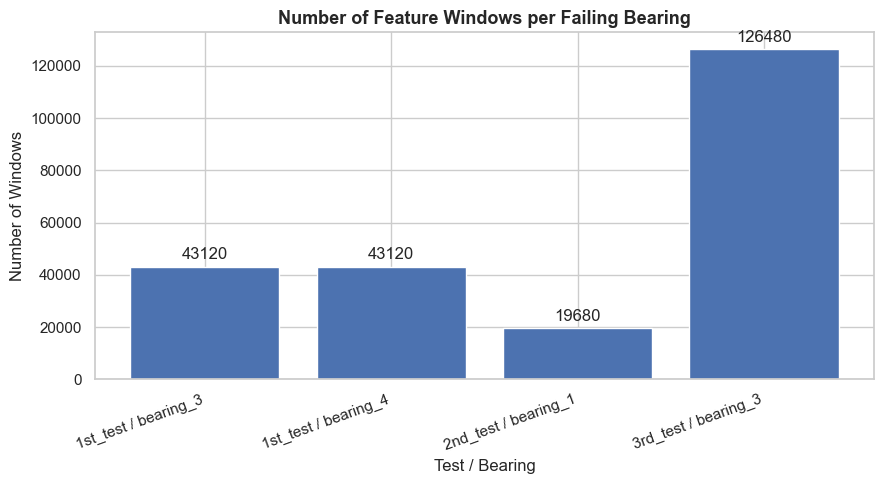

In [27]:
# ====================================================
# Windows per Bearing/Test
# ====================================================
window_counts = (
    features_df
    .groupby(["test_set", "bearing"])
    .size()
    .reset_index(name="n_windows")
)
window_counts["label"] = window_counts["test_set"] + " / " + window_counts["bearing"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(window_counts["label"], window_counts["n_windows"], color="#4C72B0")
ax.bar_label(bars, padding=3)
ax.set_title("Number of Feature Windows per Failing Bearing")
ax.set_xlabel("Test / Bearing")
ax.set_ylabel("Number of Windows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_windows_per_bearing.png")
plt.show()

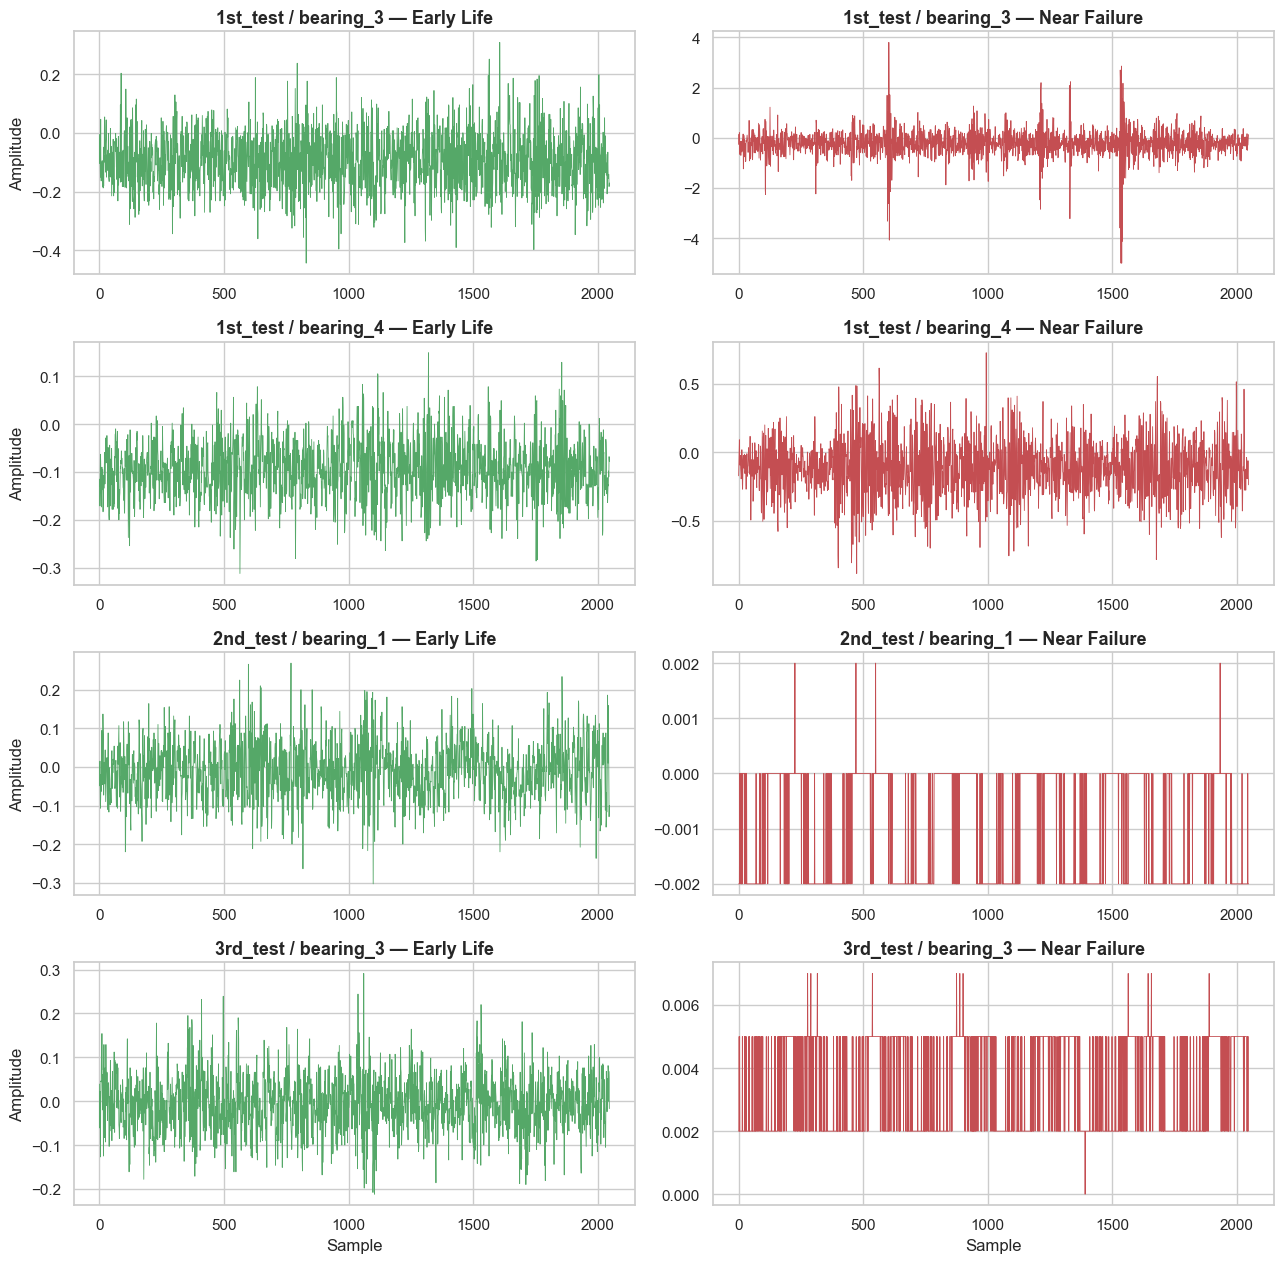

In [28]:
# ====================================================
# Raw Waveform Comparison: Early Life vs Near Failure
# ====================================================

def load_waveform(test_name, bearing_name, file_path):
    data = pd.read_csv(file_path, sep=r"\s+", header=None, engine="python")
    channel_index = CHANNEL_MAP[test_name][bearing_name]
    return data.iloc[:, channel_index].values


n_groups = len(FAILING_BEARING_GROUPS)
fig, axes = plt.subplots(n_groups, 2, figsize=(13, 3.2 * n_groups))
if n_groups == 1:
    axes = axes.reshape(1, -1)

for row, group in enumerate(FAILING_BEARING_GROUPS):
    test_name, bearing_name = group.test_set, group.bearing

    test_path = DATASET_PATH / test_name
    recording_files = sorted(get_recording_files(test_path), key=parse_timestamp)

    early_signal = load_waveform(test_name, bearing_name, recording_files[0])
    late_signal = load_waveform(test_name, bearing_name, recording_files[-1])

    axes[row, 0].plot(early_signal[:2048], linewidth=0.6, color="#55A868")
    axes[row, 0].set_title(f"{test_name} / {bearing_name} — Early Life")
    axes[row, 0].set_ylabel("Amplitude")

    axes[row, 1].plot(late_signal[:2048], linewidth=0.6, color="#C44E52")
    axes[row, 1].set_title(f"{test_name} / {bearing_name} — Near Failure")

for ax in axes[-1]:
    ax.set_xlabel("Sample")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_waveform_early_vs_late.png")
plt.show()

### Type 1 — Wears out slowly (1st_test bearings)
Think of it like a tire wearing down evenly. The whole surface gets rougher over time. So the signal just gets noisier and noisier everywhere, all the time.

Type 2 — Has one damaged spot (2nd_test / 3rd_test bearings)
Think of it like a tiny crack in one spot on a spinning wheel. Most of the time it's smooth. But every time that one damaged spot rotates past, it gives a little "thump." So the signal is quiet... quiet... quiet... spike... quiet... quiet... spike.

That's why they look different. Different damage = different shape.

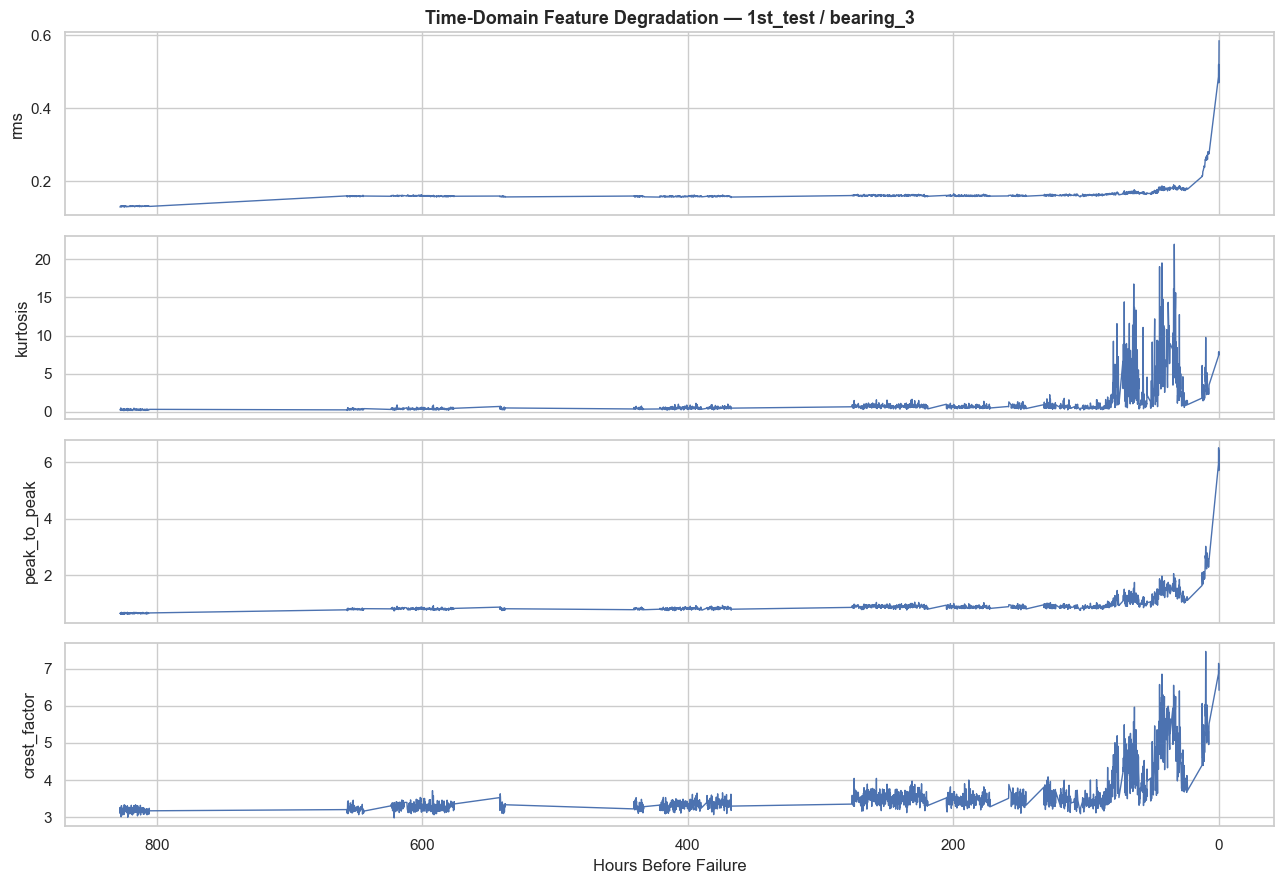

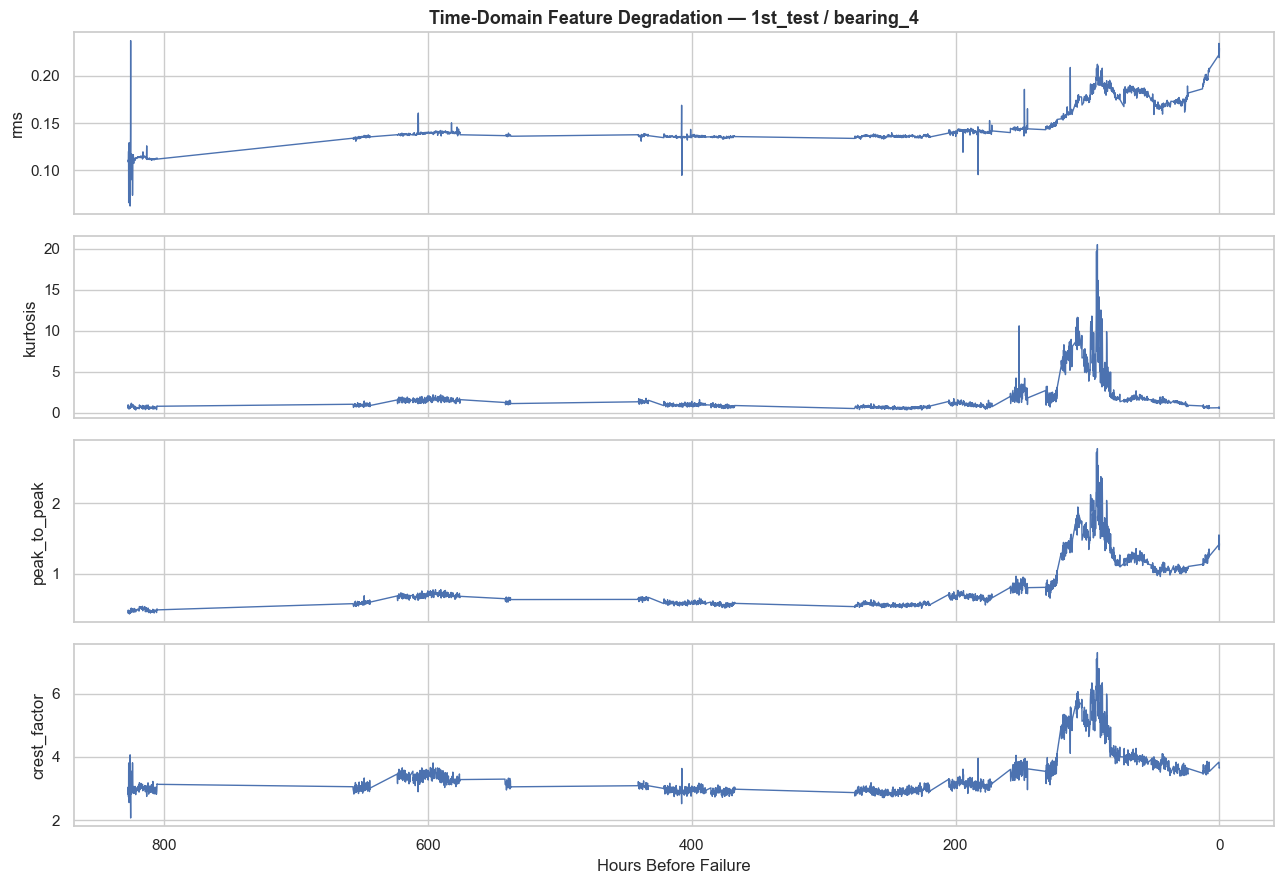

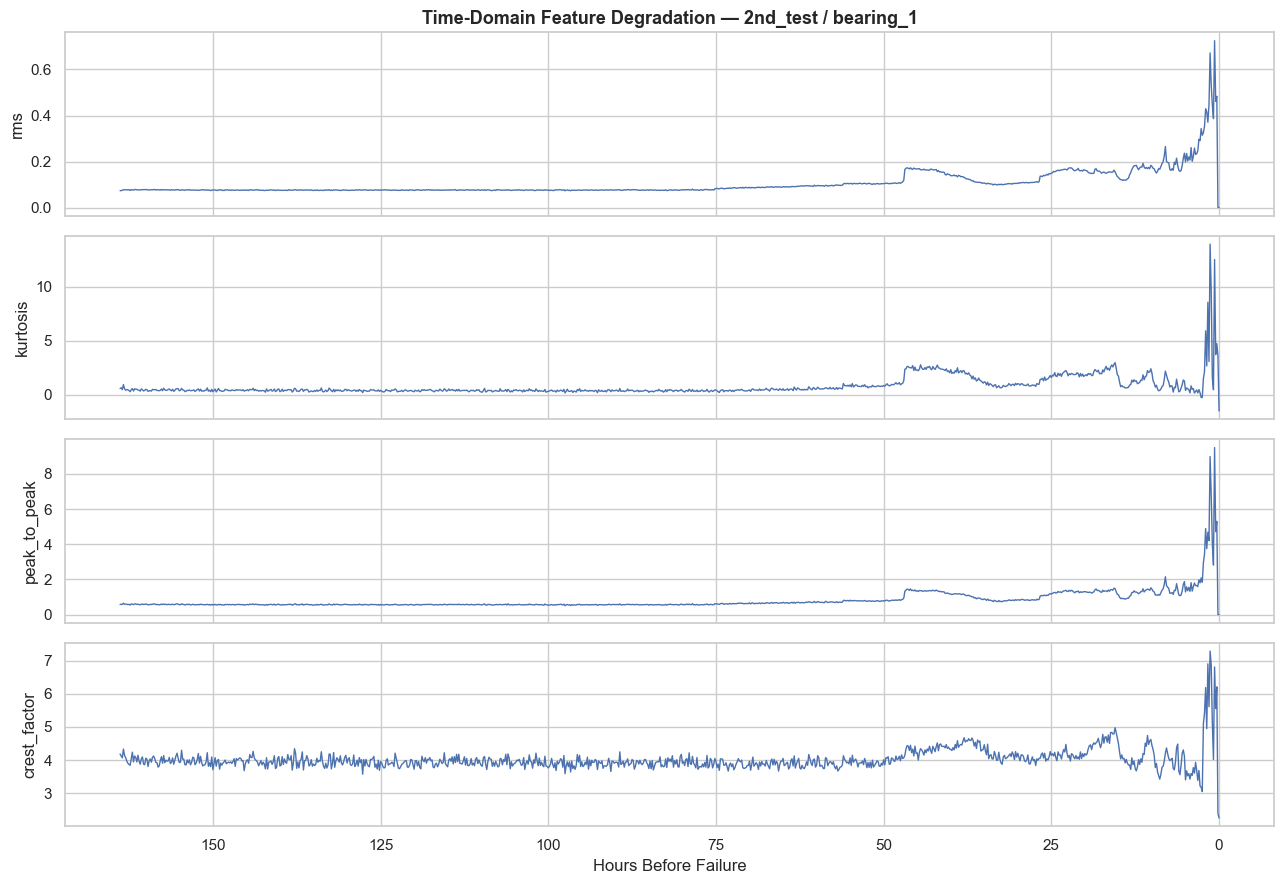

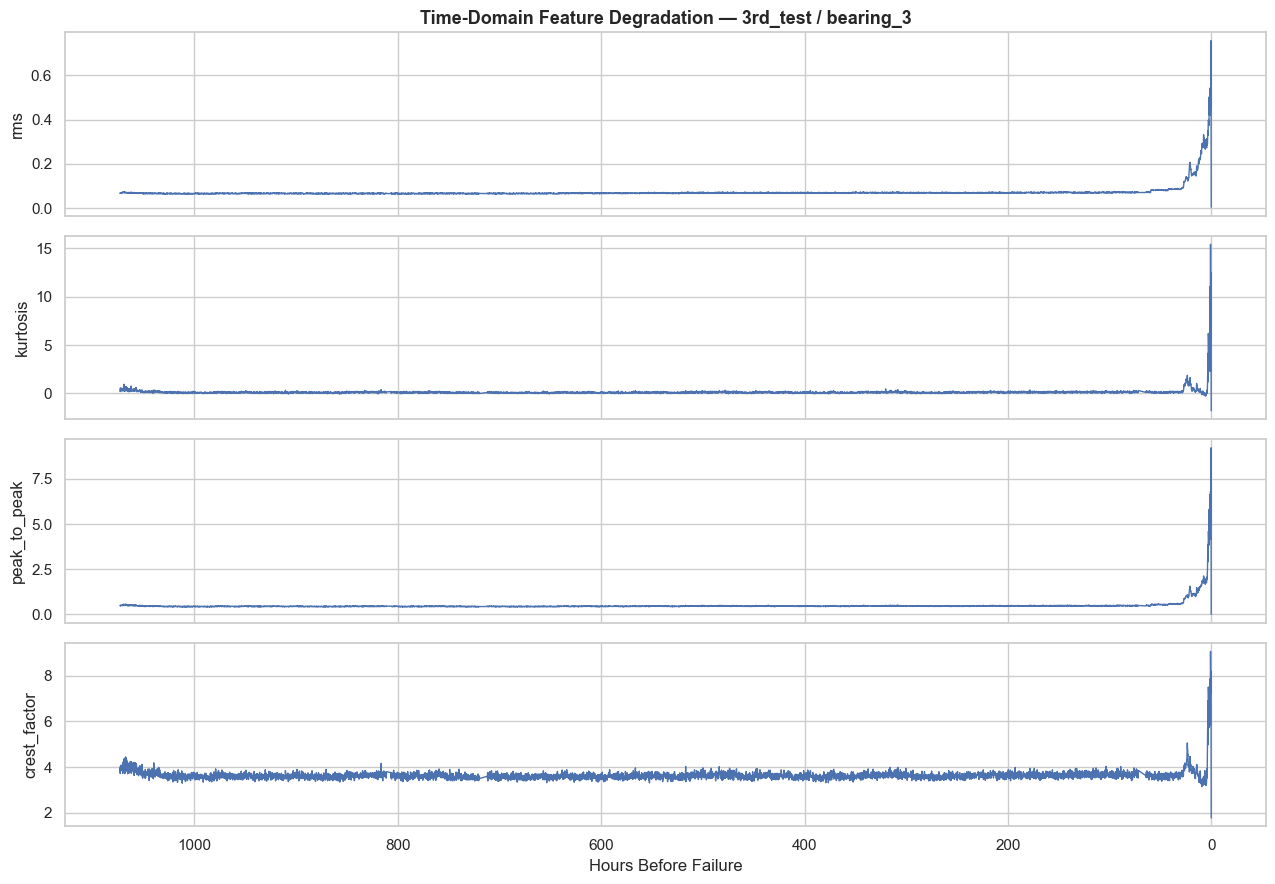

In [39]:
# ====================================================
# Time-Domain Degradation Trends (per bearing, vs hours-to-failure)
# ====================================================
TIME_FEATURES_TO_PLOT = ["rms", "kurtosis", "peak_to_peak", "crest_factor"]

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[TIME_FEATURES_TO_PLOT]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )

    fig, axes = plt.subplots(len(TIME_FEATURES_TO_PLOT), 1, figsize=(13, 9), sharex=True)

    for ax, feature in zip(axes, TIME_FEATURES_TO_PLOT):
        ax.plot(trend["RUL_hours"], trend[feature], color="#4C72B0", linewidth=1)
        ax.set_ylabel(feature)

    # Shared x-axis: invert ONCE, after the loop. Calling invert_xaxis() once
    # per subplot above toggles the shared axis back and forth, and cancels
    # out entirely on an even number of features. Left = early life, right = failure.
    axes[0].invert_xaxis()

    axes[0].set_title(f"Time-Domain Feature Degradation — {test_name} / {bearing_name}")
    axes[-1].set_xlabel("Hours Before Failure")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_time_features_{test_name}_{bearing_name}.png")
    plt.show()

### The one non-obvious thing to mention (this impresses in a presentation):
### Kurtosis sometimes drops back down even as the bearing gets worse (you can see this in bearing_3 — busy for a while, then flat again before the end). That's not the bearing healing. It's that once the defect is big enough, impacts overlap and blend into continuous noise — statistically it starts looking "smooth" again even though it's more damaged. RMS keeps rising because energy never stops increasing; kurtosis just changes character.

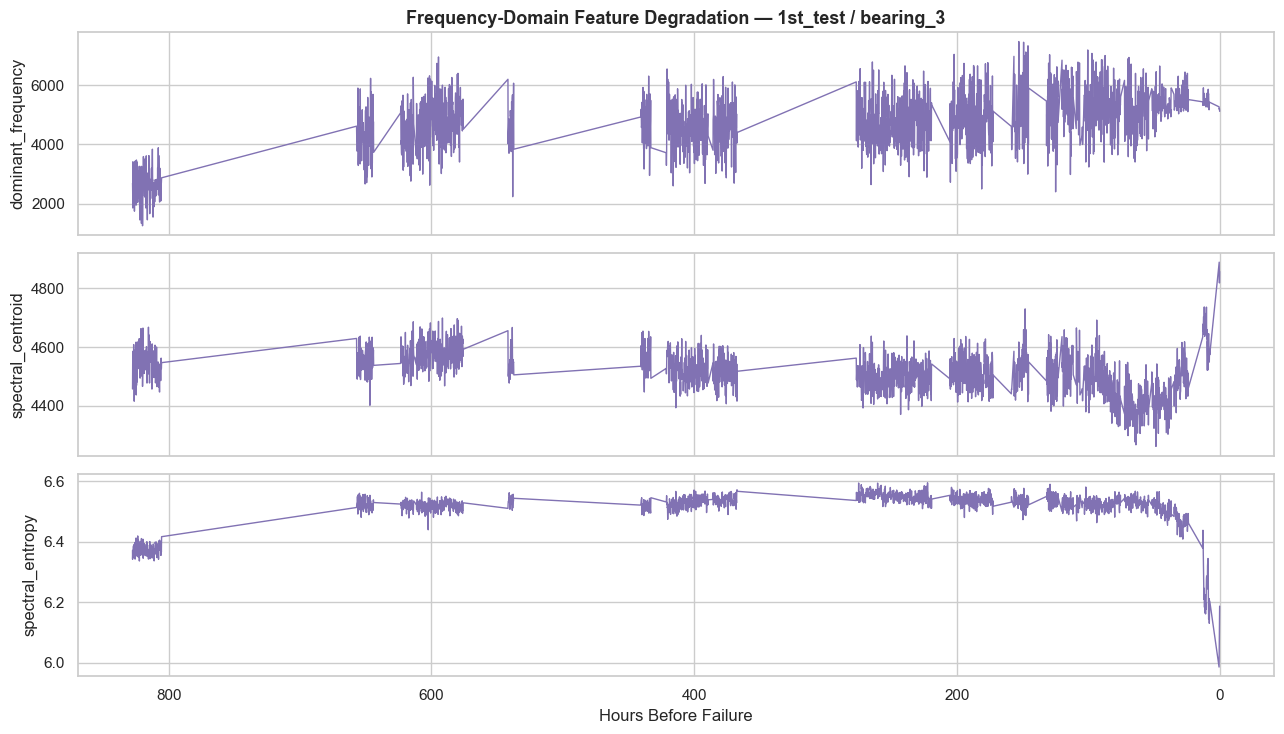

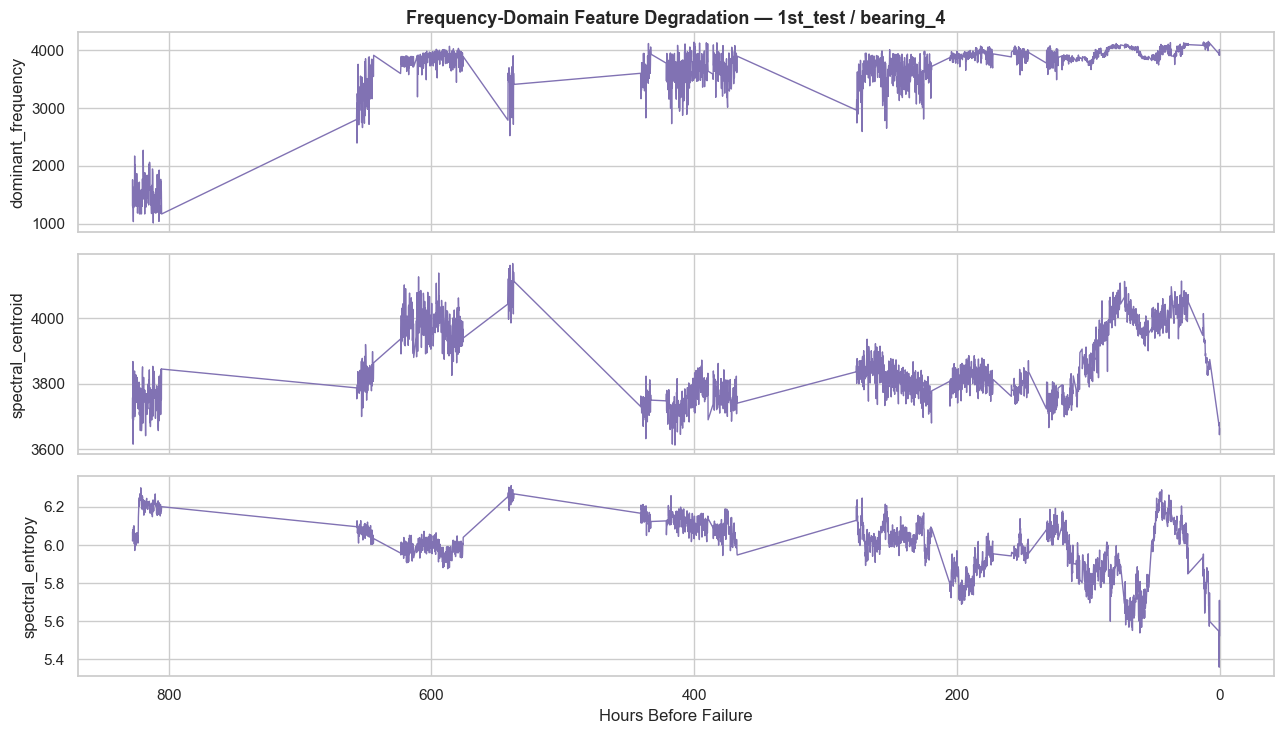

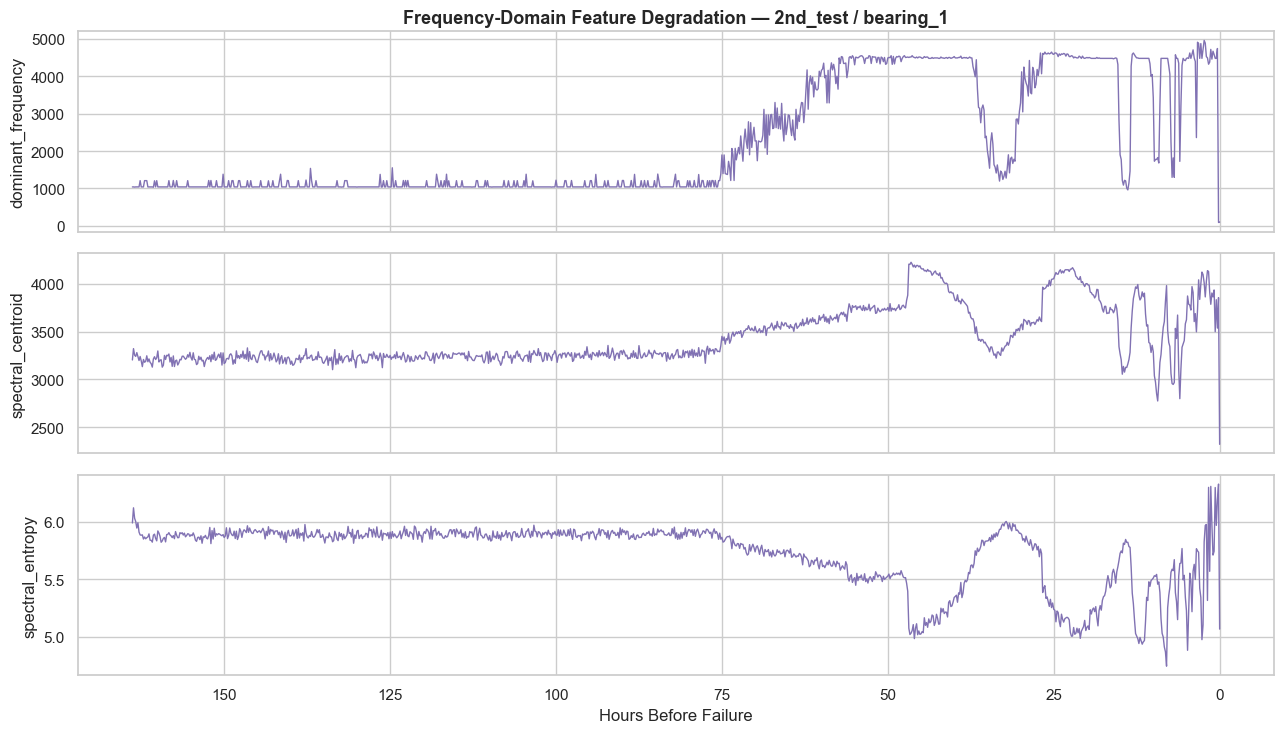

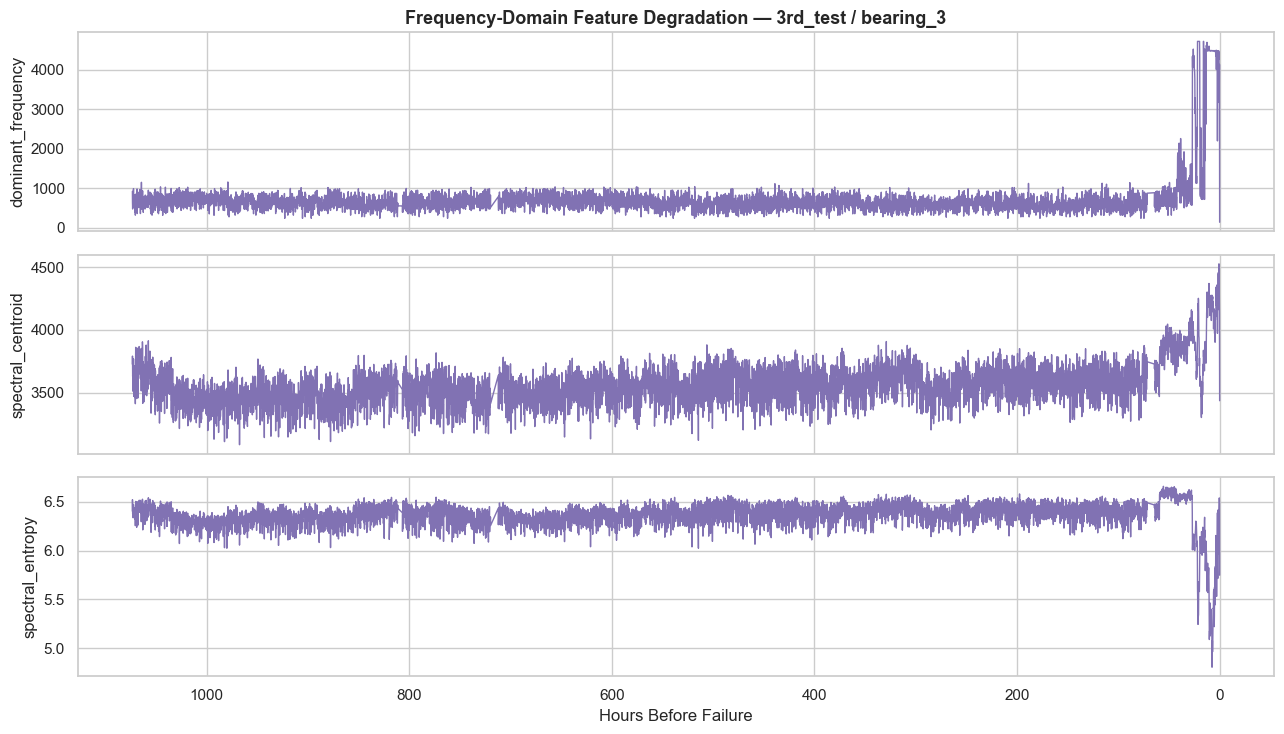

In [30]:
# ====================================================
# Frequency-Domain Degradation Trends (per bearing, vs hours-to-failure)
# ====================================================
FREQ_FEATURES_TO_PLOT = ["dominant_frequency", "spectral_centroid", "spectral_entropy"]

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[FREQ_FEATURES_TO_PLOT]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )

    fig, axes = plt.subplots(len(FREQ_FEATURES_TO_PLOT), 1, figsize=(13, 7.5), sharex=True)

    for ax, feature in zip(axes, FREQ_FEATURES_TO_PLOT):
        ax.plot(trend["RUL_hours"], trend[feature], color="#8172B3", linewidth=1)
        ax.set_ylabel(feature)
        ax.invert_xaxis()

    axes[0].set_title(f"Frequency-Domain Feature Degradation — {test_name} / {bearing_name}")
    axes[-1].set_xlabel("Hours Before Failure")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"04_freq_features_{test_name}_{bearing_name}.png")
    plt.show()

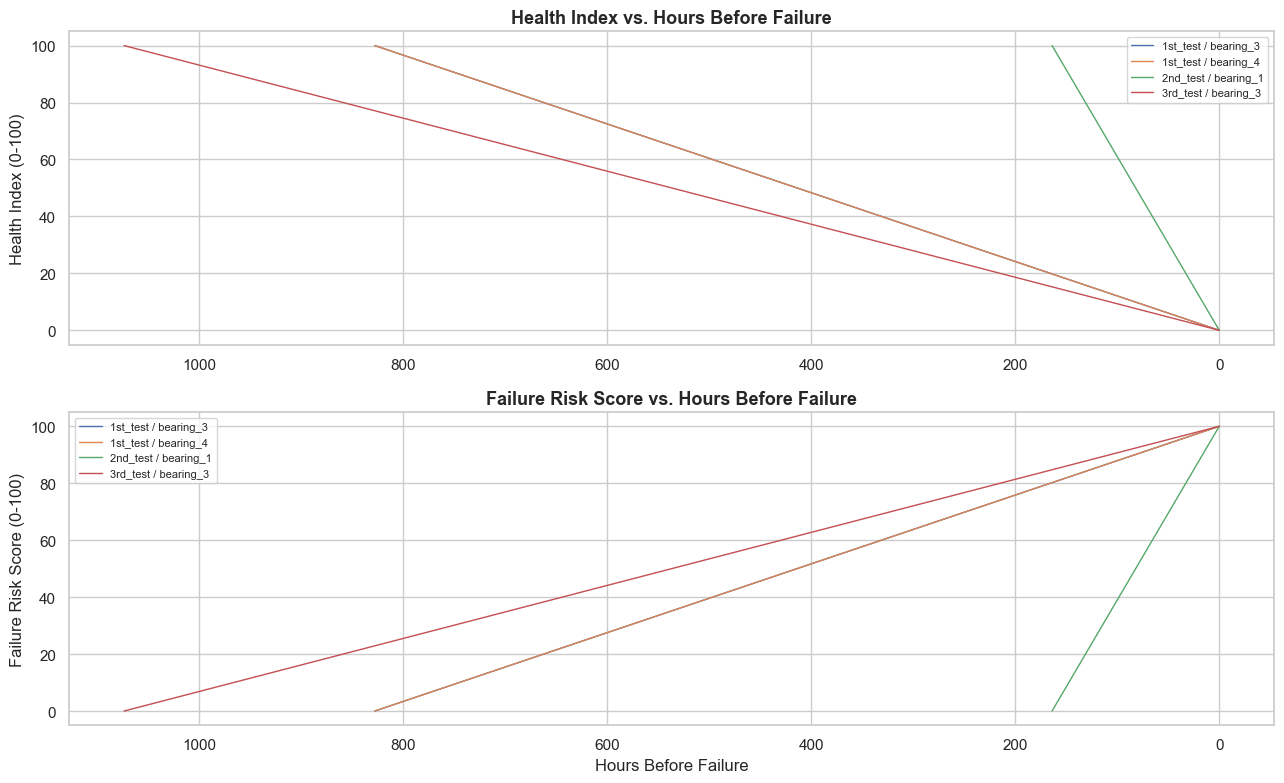

In [31]:
# ====================================================
# Health Index / Failure Risk Score vs Hours-to-Failure (all bearings)
# ====================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for group in FAILING_BEARING_GROUPS:
    test_name, bearing_name = group.test_set, group.bearing

    subset = features_df[
        (features_df["test_set"] == test_name) &
        (features_df["bearing"] == bearing_name)
    ]

    trend = (
        subset
        .groupby("RUL_hours")[["health_index", "failure_risk_score"]]
        .mean()
        .reset_index()
        .sort_values("RUL_hours", ascending=False)
    )
    label = f"{test_name} / {bearing_name}"

    axes[0].plot(trend["RUL_hours"], trend["health_index"], label=label, linewidth=1)
    axes[1].plot(trend["RUL_hours"], trend["failure_risk_score"], label=label, linewidth=1)

axes[0].set_title("Health Index vs. Hours Before Failure")
axes[0].set_ylabel("Health Index (0-100)")
axes[0].invert_xaxis()
axes[0].legend(fontsize=8)

axes[1].set_title("Failure Risk Score vs. Hours Before Failure")
axes[1].set_ylabel("Failure Risk Score (0-100)")
axes[1].set_xlabel("Hours Before Failure")
axes[1].invert_xaxis()
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_health_index_failure_risk.png")
plt.show()

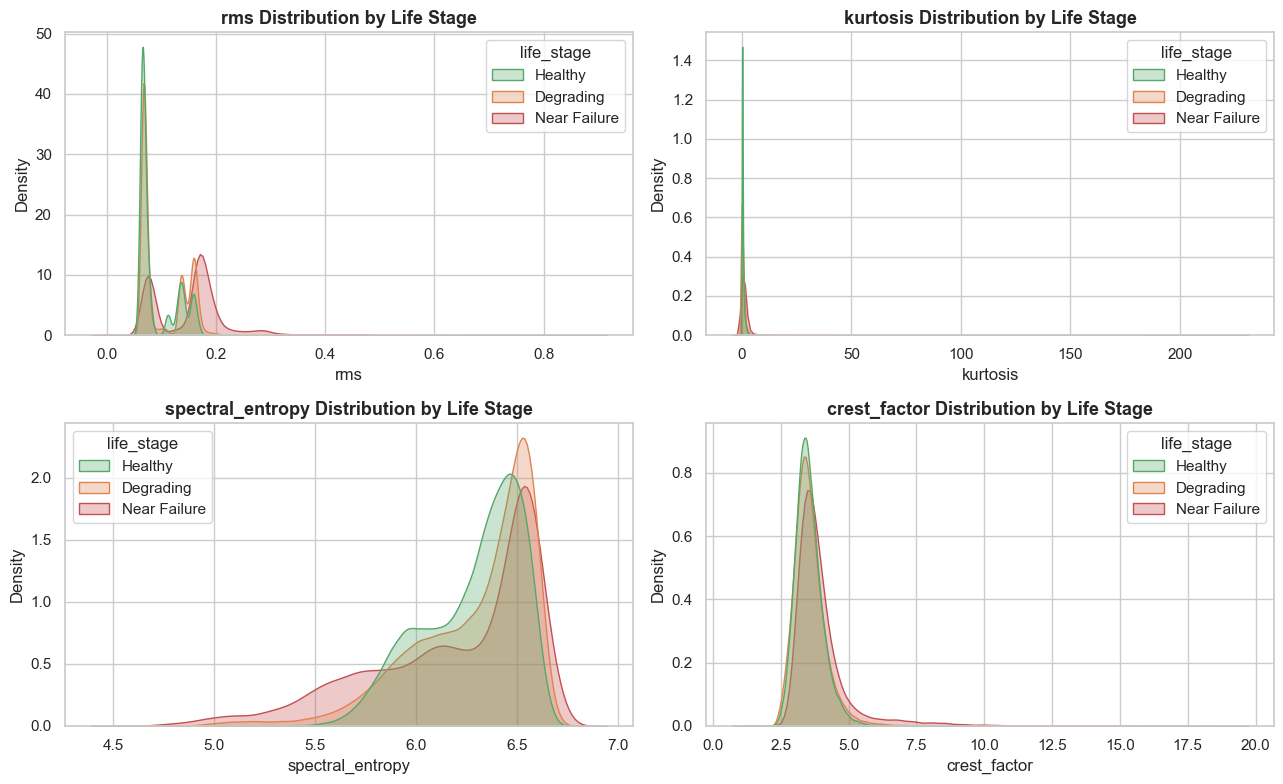

In [32]:
# ====================================================
# Distribution Shift Across Life Stages
# ====================================================
DIST_FEATURES = ["rms", "kurtosis", "spectral_entropy", "crest_factor"]

features_df["life_stage"] = np.select(
    [features_df["RUL_fraction"] > 0.7, features_df["RUL_fraction"] < 0.1],
    ["Healthy", "Near Failure"],
    default="Degrading"
)

palette = {"Healthy": "#55A868", "Degrading": "#DD8452", "Near Failure": "#C44E52"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, feature in zip(axes, DIST_FEATURES):
    sns.kdeplot(
        data=features_df,
        x=feature,
        hue="life_stage",
        hue_order=["Healthy", "Degrading", "Near Failure"],
        palette=palette,
        fill=True,
        alpha=0.3,
        common_norm=False,
        ax=ax
    )
    ax.set_title(f"{feature} Distribution by Life Stage")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_feature_distributions_life_stage.png")
plt.show()

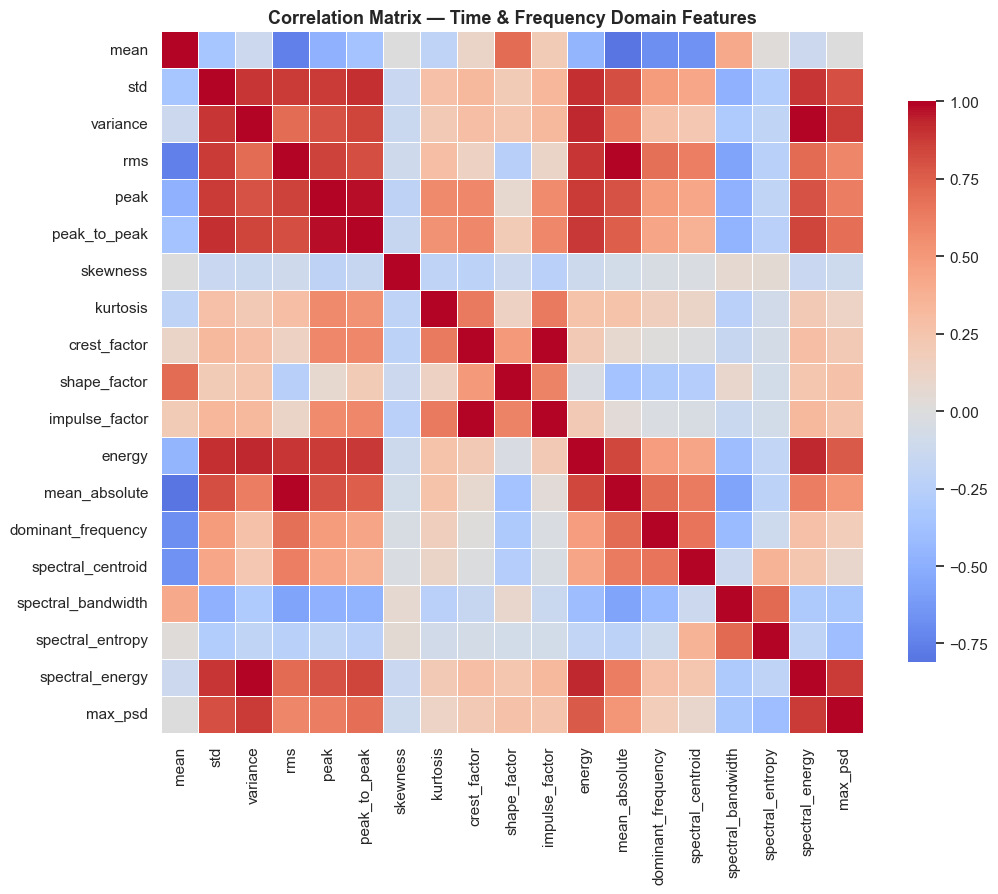

In [33]:
# ====================================================
# Correlation Matrix — Time & Frequency Domain Features
# ====================================================
NUMERIC_FEATURE_COLS = [
    "mean", "std", "variance", "rms", "peak", "peak_to_peak",
    "skewness", "kurtosis", "crest_factor", "shape_factor",
    "impulse_factor", "energy", "mean_absolute",
    "dominant_frequency", "spectral_centroid", "spectral_bandwidth",
    "spectral_entropy", "spectral_energy", "max_psd"
]

corr_matrix = features_df[NUMERIC_FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Correlation Matrix — Time & Frequency Domain Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_feature_correlation_heatmap.png")
plt.show()

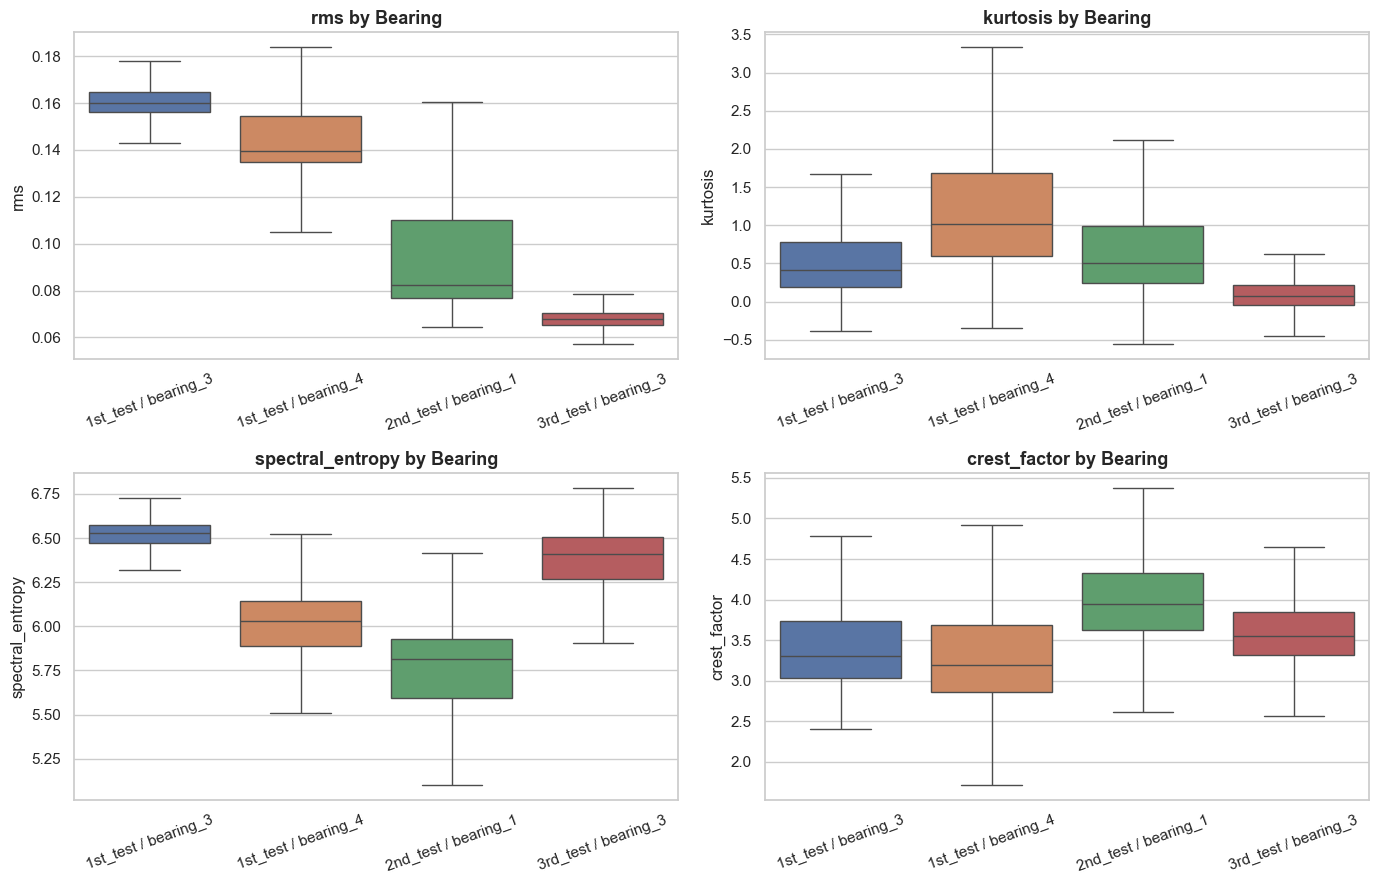

In [34]:
# ====================================================
# Feature Spread by Bearing
# ====================================================
features_df["group"] = features_df["test_set"] + " / " + features_df["bearing"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, feature in zip(axes, DIST_FEATURES):
    sns.boxplot(
        data=features_df,
        x="group",
        y=feature,
        hue="group",
        palette="deep",
        legend=False,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f"{feature} by Bearing")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_feature_boxplots_by_bearing.png")
plt.show()

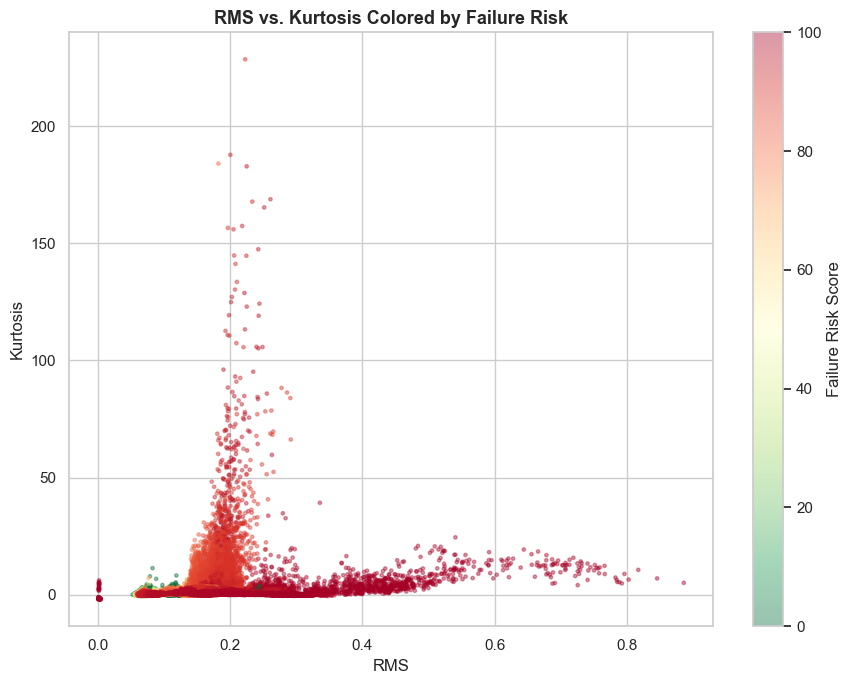

In [35]:
# ====================================================
# RMS vs Kurtosis Scatter — Failure Progression
# ====================================================
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    features_df["rms"],
    features_df["kurtosis"],
    c=features_df["failure_risk_score"],
    cmap="RdYlGn_r",
    s=6,
    alpha=0.4
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Failure Risk Score")
ax.set_xlabel("RMS")
ax.set_ylabel("Kurtosis")
ax.set_title("RMS vs. Kurtosis Colored by Failure Risk")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_rms_vs_kurtosis_risk.png")
plt.show()

In [50]:
# ====================================================
# Summary Statistics Table
# ====================================================
summary_stats = (
    features_df
    .groupby(["test_set", "bearing"])[NUMERIC_FEATURE_COLS]
    .agg(["mean", "std", "min", "max"])
)
summary_stats

mean                                     std  \
                        mean       std       min       max      mean   
test_set bearing                                                       
1st_test bearing_3 -0.112761  0.010216 -0.243764  0.537065  0.115125   
         bearing_4 -0.112849  0.008290 -0.234787  0.017646  0.091390   
2nd_test bearing_1 -0.001943  0.002810 -0.037029  0.027100  0.105967   
3rd_test bearing_3 -0.002073  0.003780 -0.360870  0.411486  0.072243   

                                                  variance            ...  \
                         std       min       max      mean       std  ...   
test_set bearing                                                      ...   
1st_test bearing_3  0.024332  0.079160  0.778452  0.013846  0.012213  ...   
         bearing_4  0.029332  0.048812  0.265877  0.009212  0.006566  ...   
2nd_test bearing_1  0.058358  0.000879  0.765265  0.014634  0.030573  ...   
3rd_test bearing_3  0.030792  0.001490  0.854622  0.006167  0.014339  ...   

                   spectral_entropy           spectral_energy            \
                                min       max            mean       std   
test_set bearing                                                          
1st_test bearing_3         5.189735  6.738315        0.000173  0.000157   
         bearing_4         4.931278  6.594852        0.000115  0.000084   
2nd_test bearing_1         4.552171  6.620348        0.000181  0.000382   
3rd_test bearing_3         4.623731  6.782413        0.000076  0.000173   

                                             max_psd                          \
                             min       max      mean       std           min   
test_set bearing                                                               
1st_test bearing_3  7.640319e-05  0.008378  0.000008  0.000016  2.803596e-06   
         bearing_4  2.719083e-05  0.000950  0.000010  0.000010  1.456928e-06   
2nd_test bearing_1  8.931479e-09  0.007450  0.000020  0.000038  5.245115e-10   
3rd_test bearing_3  2.477484e-08  0.007881  0.000007  0.000021  2.950198e-09   

                              
                         max  
test_set bearing              
1st_test bearing_3  0.001218  
         bearing_4  0.000129  
2nd_test bearing_1  0.000705  
3rd_test bearing_3  0.000639  

[4 rows x 76 columns]